<h1 align="center">
    NSDC Data Science Projects
</h1>
  
<h2 align="center">
    Quantum computing: A Data Science approach
</h2>

<h3 align="center">
    Name: hellosmallkat
</h3>




---



### **Please read before you begin your project**

**Instructions: Google Colab Notebooks:**

Google Colab is a free cloud service. It is a hosted Jupyter notebook service that requires no setup to use, while providing free access to computing resources. We will be using Google Colab for this project.

Certain parts of this project will be completed individually, while other parts are encouraged to be completed with the rest of your team. In order to work within the Google Colab Notebook, **please start by clicking on "File" and then "Save a copy in Drive."** This will save a copy of the notebook in your personal Google Drive. Each member of your team should work on their personal copy.

Please rename the file to "TITLE - Your Full Name." Once this project is completed, you will be prompted to share your file with the National Student Data Corps (NSDC) Project Leaders.

You can now start working on the project. :)

We'll be using Google Colab for this assignment. This is a Python Notebook environment built by Google that's free for everyone and comes with a nice UI out of the box. For a comprehensive guide, see Colab's official guide [here](https://colab.research.google.com/github/prites18/NoteNote/blob/master/Welcome_To_Colaboratory.ipynb).

Colab QuickStart:
- Notebooks are made up of cells, cells can be either text or code cells. Click the +code or +text button at the top to create a new cell
- Text cells use a format called [Markdown](https://www.markdownguide.org/getting-started/). Cheatsheet is available [here](https://www.markdownguide.org/cheat-sheet/)
- Python code is run/executed in code cells. You can click the play button at the top left of a code block (sometimes hidden in the square brackets) to run the code in that cell. You an also hit shift+enter to run the cell that is currently selected. There is no concurrency since cells run one at a time but you can queue up multiple cells
- Each cell will run code individually but memory is shared across a notebook Runtime. You can think of a Runtime as a code session where everything you create and execute is temporarily stored. This means variables and functions are available between cells if you execute one cell before the other (physical ordering of cells does not matter). This also means that if you delete or change the name of something and re-execute the cell, the old data might still exist in the background. If things aren't making sense, you can always click Runtime -> restart runtime to start over.
- Runtimes will persist for a short period of time so you are safe if you lose connection or refresh the page but Google will shutdown a runtime after enough time has past. Everything that was printed out will remain on the page even if the runtime is disconnected
- Google's Runtimes come preinstalled with all the core python libraries (math, rand, time, etc) as well as common data analysis libraries (numpy, pandas, scikitlearn, matplotlib). Simply run `import numpy as np` in a code cell to make it available.

# **Introduction**
---
Before we jump into any code, let's talk about something that honestly matters just as much as the technical stuff. How we build AI and who it affects.
Think about it. AI is already a huge part of our lives. It recommends what you watch, helps doctors catch diseases early, and even plays a role in decisions like who gets hired or who gets approved for a loan. That's a lot of influence. And when something has that much power over people's lives, we have to be thoughtful about how we build it and what it's actually doing.
That's where Ethical and Responsible AI (ERAI) comes in. It's really just about asking the right questions.

*   Is it fair? Is this AI treating everyone equally?
Does it work the same for all groups of people?
Who could be left out or negatively affected?
*   Is it transparent? Can we explain what the AI is doing?
Can we understand why it made a certain decision?
Would a regular person be able to make sense of it?
*   Is it responsible? Are we doing more good than harm?
Who is accountable when something goes wrong?
How do we make it better over time?

In this notebook, we won't just learn how to build AI. We'll learn how to think about it too.

# **Milestone 1: Setup and Quantum foundations**

## Why do we need quantum computers?
---


Classical computers are extraordinary. A modern chip has over 100 billion transistors,
runs at 3-5 billion operations per second, and powers everything from your phone to
large language models. So why do we need something different?

Because some problems do not just get harder as they get bigger, they get
*exponentially* harder. Adding one more variable can double the time to solve them.
At a certain scale, no classical computer, ever, can crack them.

These are not toy problems. They include things data scientists care about deeply:

**1. Search at scale**
Finding the optimal record in an unsorted dataset of N items takes O(N) steps classically.
Quantum computers do it in O(sqrt(N)). For a trillion records: 1 trillion vs. 1 million steps.

**2. Combinatorial optimization**
Finding the best feature subset from 50 features means checking 2^50 combinations.
That is over 1 quadrillion possibilities. Classical computers approximate. Quantum computers
can explore exponential spaces more efficiently.

**3. Molecular simulation**
Simulating a molecule for drug discovery requires tracking quantum states of electrons.
For 50 atoms, the state space has 2^50 dimensions. Classical computers cannot do this exactly.
Quantum computers simulate quantum systems naturally.


### A brief history: how did we get here?

In 1981, physicist Richard Feynman made a blunt observation: to simulate quantum systems accurately, you'd need a computer that *itself* operates quantum mechanically. Classical computers simply can't keep up with how nature computes behind the scenes.

> *"Nature isn't classical, damnit, and if you want to make a simulation of nature, you'd better make it quantum mechanical."*
> — Richard Feynman, 1981

Feynman, along with David Deutsch and others, proposed building computers whose logic was quantum-mechanical from the start. That's the idea this notebook builds on.

### Key Terms for Milestone 1

| Term | Plain-English Definition |
|------|--------------------------|
| **Bit** | The basic unit of classical computing. Either 0 or 1. |
| **Exponential growth** | When adding 1 to problem size *doubles* (or more) the work needed. |
| **O(N) / O(√N)** | Shorthand for "how many steps it takes" as problem size N grows. |
| **Qubit** | The quantum equivalent of a bit. You'll learn more in Milestone 2! |
| **Qiskit** | IBM's open-source Python library for building quantum circuits. We'll use it throughout. |

**Step 1:** Let's begin with the setup and the libraries we will be using.

In [ ]:
# Run this cell first, it installs everything the notebook needs
!pip install qiskit qiskit-aer matplotlib numpy networkx scipy -q
print('Libraries ready. Move on to step 2!')

Libraries ready. Move on to step 2!


**Step 2:** Run the next cell to install the most important imports.

In [ ]:
# Core imports used throughout the notebook
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix

# Seed everything we can so results are reproducible across runs
SEED = 42
np.random.seed(SEED)
simulator = AerSimulator(seed_simulator=SEED)

# Note: we are NOT globally suppressing warnings. If Qiskit prints a
# DeprecationWarning, that's useful information: it tells you the API is
# about to change. Read them, don't hide them.

print('Ready to go! Move on to Milestone 2')

Ready to go! Move on to Milestone 2


**Step 3:** Let's continue by understanding the exponential gap and the reason for quantum computing. Run the next cell.

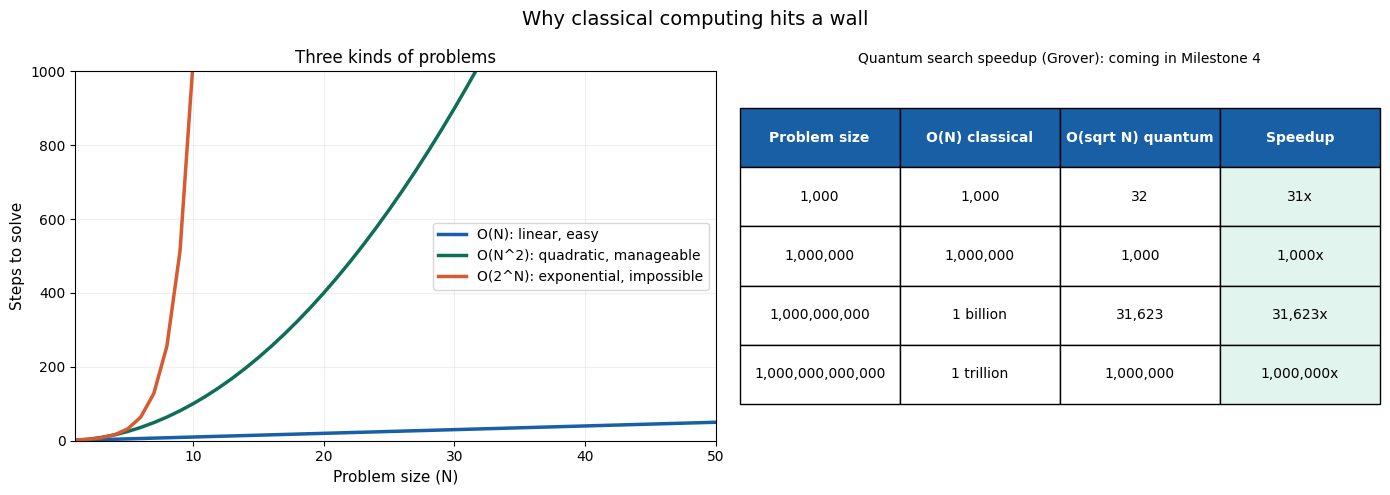

In [ ]:
# The exponential gap: visualized
# This is the core motivation for quantum computing

problem_sizes = np.arange(1, 51)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Why classical computing hits a wall', fontsize=14)

# Left: all three curves
axes[0].plot(problem_sizes, problem_sizes,
             lw=2.5, color='#185FA5', label='O(N): linear, easy')
axes[0].plot(problem_sizes, problem_sizes**2,
             lw=2.5, color='#0F6E56', label='O(N^2): quadratic, manageable')
axes[0].plot(problem_sizes, 2**problem_sizes,
             lw=2.5, color='#D85A30', label='O(2^N): exponential, impossible')
axes[0].set_ylim(0, 1000)
axes[0].set_xlim(1, 50)
axes[0].set_xlabel('Problem size (N)', fontsize=11)
axes[0].set_ylabel('Steps to solve', fontsize=11)
axes[0].set_title('Three kinds of problems')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.2)

# Right: real-world consequence table
axes[1].axis('off')
table_data = [
    ['Problem size', 'O(N) classical', 'O(sqrt N) quantum', 'Speedup'],
    ['1,000', '1,000', '32', '31x'],
    ['1,000,000', '1,000,000', '1,000', '1,000x'],
    ['1,000,000,000', '1 billion', '31,623', '31,623x'],
    ['1,000,000,000,000', '1 trillion', '1,000,000', '1,000,000x'],
]
table = axes[1].table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc='center',
    loc='center',
    bbox=[0, 0.1, 1, 0.8]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#185FA5')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 3:
        cell.set_facecolor('#E1F5EE')
axes[1].set_title('Quantum search speedup (Grover): coming in Milestone 4', fontsize=10)

plt.tight_layout()
plt.show()

**Step 4:** Now we will understand the classical brute-force approach and how it breaks

In [ ]:
# Classical brute-force search: watch it break at scale

#TODO

# **Milestone 2: Quantum Data Representation**

---
## How does quantum computing store information?
A classical computer stores data as **bits**: tiny electrical switches that are either
OFF (0) or ON (1). Every number, image, model weight, and dataset lives as a sequence
of these switches.

A quantum computer stores data as **qubits**. The difference is not only technical but also conceptual.

## The qubit as a probability distribution

A classical bit is *definite*: exactly 0 or 1 at all times.

A qubit before measurement is a **superposition**: it holds a 0 and a 1 simultaneously,
each with a probability. When you measure it, it collapses to one value, randomly,
weighted by those probabilities.

Written mathematically:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$$

Where:
- alpha^2 = probability of measuring 0
- beta^2 = probability of measuring 1
- alpha^2 + beta^2 = 1 (must sum to 100%)

**The data science framing:** think of a qubit like a Bernoulli random variable. Before you measure it, it holds a probability distribution. Measuring it *samples* from that distribution, and the sample is the only value you get.

## Why does this give us power?

With N classical bits you store exactly ONE N-bit number.
With N qubits in superposition you simultaneously represent 2^N states, every possible
N-bit number at once, each with its own amplitude.

| Qubits | States represented simultaneously |
|--------|----------------------------------|
| 2 | 4 |
| 10 | 1,024 |
| 30 | 1,073,741,824 |
| 50 | 1,125,899,906,842,624 |
| 300 | More than atoms in the observable universe |

The art of quantum computing is manipulating those 2^N states so the right answer
ends up with high probability when you measure. Let's see this in practice!

### Key Terms for Milestone 2

| Term | Plain-English Definition |
|------|--------------------------|
| **Qubit** | A quantum bit that can be 0, 1, or a superposition of both |
| **Superposition** | Being in multiple states at once (with different probabilities) |
| **Amplitude** | The complex number controlling a state's probability (prob = amplitude²) |
| **Measurement** | The act of "looking" at a qubit, which collapses its superposition |
| **Bloch sphere** | A 3D ball used to visualize all possible qubit states geometrically |

**Step 1**: Let's see the probability distribution of a qubit

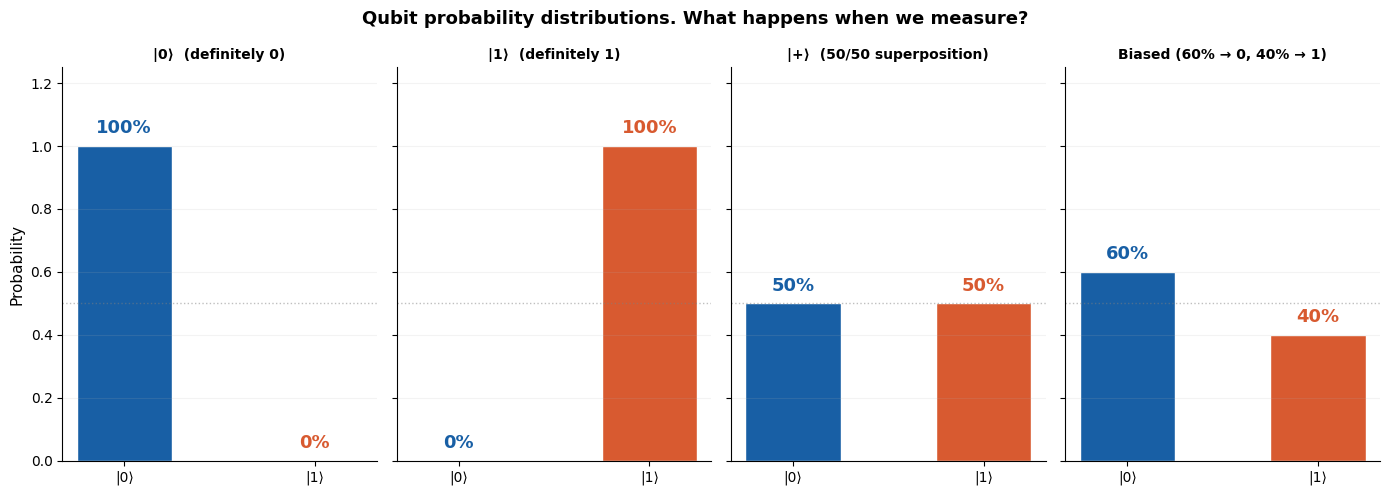


Notice:
  - |0⟩ and |1⟩ are like classical bits. Completely certain outcomes.
  - |+⟩ is a true superposition 50/50, like a fair coin toss.
  - The biased qubit is like a weighted coin, one side more likely.

Key point: BEFORE measurement, the qubit holds the full distribution.
AFTER measurement, it collapses to a single value and stays there.


In [ ]:
# Visualizing qubit probability distributions
# Each bar chart shows: "if I measured this qubit right now, what would I get?"

# The three states we'll look at
#  |0>  : definitely 0  (alpha=1, beta=0)
#  |1>  : definitely 1  (alpha=0, beta=1)
#  |+>  : perfect 50/50 superposition (alpha=1/√2, beta=1/√2)
#  |60> : biased — 60% chance of 0, 40% chance of 1

states = {
    '|0⟩  (definitely 0)':         [1.0, 0.0],   # [P(0), P(1)]
    '|1⟩  (definitely 1)':         [0.0, 1.0],
    '|+⟩  (50/50 superposition)':  [0.5, 0.5],
    'Biased (60% → 0, 40% → 1)':  [0.6, 0.4],
}

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)
fig.suptitle('Qubit probability distributions. What happens when we measure?',
             fontsize=13, fontweight='bold')

colors_0 = '#185FA5'   # blue for |0>
colors_1 = '#D85A30'   # orange for |1>

for ax, (label, probs) in zip(axes, states.items()):
    bars = ax.bar(['|0⟩', '|1⟩'], probs,
                  color=[colors_0, colors_1], edgecolor='white', width=0.5)
    ax.set_ylim(0, 1.25)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Probability' if ax == axes[0] else '', fontsize=11)

    # Label each bar with its probability value
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.04,
                f'{p:.0%}',
                ha='center', fontsize=13, fontweight='bold',
                color=bar.get_facecolor())

    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, lw=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.15, axis='y')

plt.tight_layout()
plt.show()

print()
print('Notice:')
print('  - |0⟩ and |1⟩ are like classical bits. Completely certain outcomes.')
print('  - |+⟩ is a true superposition 50/50, like a fair coin toss.')
print('  - The biased qubit is like a weighted coin, one side more likely.')
print()
print('Key point: BEFORE measurement, the qubit holds the full distribution.')
print('AFTER measurement, it collapses to a single value and stays there.')

**Step 2:** The **Bloch sphere** is a 3D visualization of all possible qubit states. Instead of just showing probabilities, it captures the full information stored in a qubit, including something called *phase*, which we'll explore in Milestone 3.

Think of the Bloch sphere like a globe:
- The **North Pole** = definitely |0⟩
- The **South Pole** = definitely |1⟩
- The **Equator** = equal superposition (50/50 chance of 0 or 1, but with different phases)


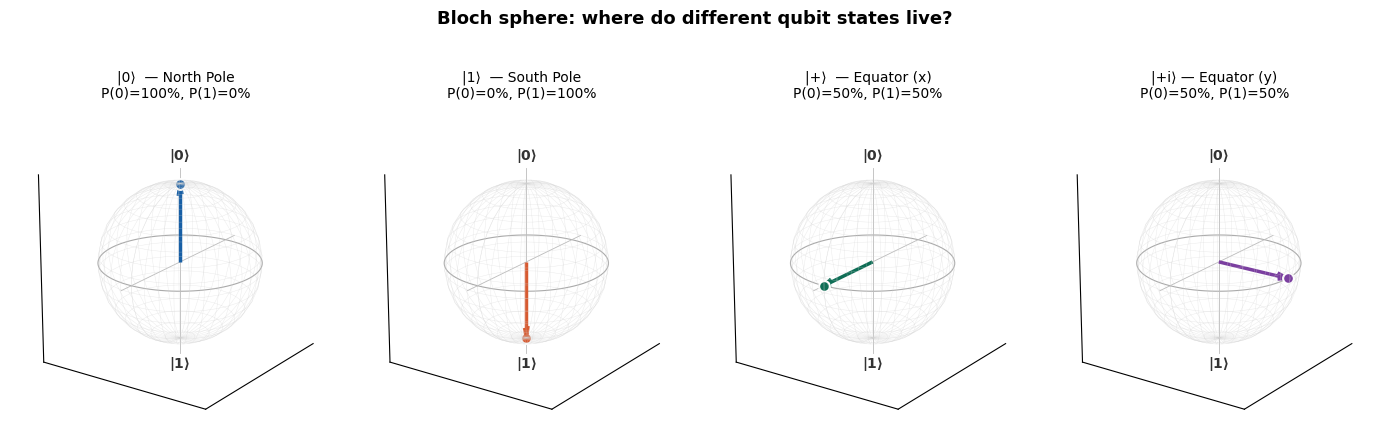


What you are seeing:
  |0⟩  →  Arrow points UP   (North Pole): this qubit is definitely 0.
  |1⟩  →  Arrow points DOWN (South Pole): this qubit is definitely 1.
  |+⟩  →  Arrow on Equator:  50/50 superposition, phase pointing +x.
  |+i⟩ →  Same 50/50 odds, but different phase — pointing +y instead.

The arrow direction encodes EVERYTHING about the qubit.
Same arrow length (all = 1) means all qubits are "pure" states.


In [ ]:
# Bloch sphere visualization (a map of all possible qubit states)
from mpl_toolkits.mplot3d import Axes3D

def draw_bloch_sphere(ax, state_vector, title, color='#185FA5'):
    """
    Draw a labeled Bloch sphere and mark where a qubit state lives on it.
    The qubit state is the arrow. Its direction encodes everything about the qubit.
    """
    a, b = state_vector[0], state_vector[1]

    # Bloch vector coordinates (x, y, z). These come from the qubit amplitudes
    bx = 2 * (a.conjugate() * b).real     # x-axis
    by = 2 * (a.conjugate() * b).imag     # y-axis
    bz = abs(a)**2 - abs(b)**2            # z-axis (positive = closer to |0>)

    # Draw the sphere wireframe
    u = np.linspace(0, 2 * np.pi, 36)
    v = np.linspace(0, np.pi, 18)
    ax.plot_wireframe(np.outer(np.cos(u), np.sin(v)),
                      np.outer(np.sin(u), np.sin(v)),
                      np.outer(np.ones_like(u), np.cos(v)),
                      color='lightgray', lw=0.3, alpha=0.5)

    # Equator ring and axes
    th = np.linspace(0, 2 * np.pi, 100)
    ax.plot(np.cos(th), np.sin(th), np.zeros_like(th), color='#aaa', lw=0.8)
    ax.plot([-1.2, 1.2], [0, 0], [0, 0], color='#bbb', lw=0.6)
    ax.plot([0, 0], [0, 0], [-1.2, 1.2], color='#bbb', lw=0.6)

    # Pole labels
    ax.text(0, 0,  1.3, '|0⟩', fontsize=10, ha='center', color='#333', fontweight='bold')
    ax.text(0, 0, -1.4, '|1⟩', fontsize=10, ha='center', color='#333', fontweight='bold')

    # Draw the state vector arrow
    ax.quiver(0, 0, 0, bx, by, bz, color=color, lw=2.5, arrow_length_ratio=0.15)
    ax.scatter([bx], [by], [bz], color=color, s=60, edgecolor='white', lw=1.5, zorder=5)

    # Probability annotation
    p0 = abs(a)**2
    p1 = abs(b)**2
    ax.set_title(f'{title}\nP(0)={p0:.0%}, P(1)={p1:.0%}', fontsize=10, pad=2)

    ax.set(xlim=(-1.2, 1.2), ylim=(-1.2, 1.2), zlim=(-1.2, 1.2))
    ax.set_box_aspect([1, 1, 1])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.view_init(elev=20, azim=35)
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.fill = False; pane.set_edgecolor('none')

# Four interesting qubit states
s2 = 1 / np.sqrt(2)
qubit_states = [
    (np.array([1+0j, 0+0j]),             '|0⟩  — North Pole',    '#185FA5'),
    (np.array([0+0j, 1+0j]),             '|1⟩  — South Pole',    '#D85A30'),
    (np.array([s2+0j, s2+0j]),           '|+⟩  — Equator (x)',   '#0F6E56'),
    (np.array([s2+0j, s2*1j]),           '|+i⟩ — Equator (y)',   '#7B3FA0'),
]

fig = plt.figure(figsize=(14, 5))
fig.suptitle('Bloch sphere: where do different qubit states live?',
             fontsize=13, fontweight='bold')

for i, (state, label, color) in enumerate(qubit_states):
    ax = fig.add_subplot(1, 4, i + 1, projection='3d')
    draw_bloch_sphere(ax, state, label, color=color)

plt.tight_layout()
plt.show()

print()
print('What you are seeing:')
print('  |0⟩  →  Arrow points UP   (North Pole): this qubit is definitely 0.')
print('  |1⟩  →  Arrow points DOWN (South Pole): this qubit is definitely 1.')
print('  |+⟩  →  Arrow on Equator:  50/50 superposition, phase pointing +x.')
print('  |+i⟩ →  Same 50/50 odds, but different phase — pointing +y instead.')
print()
print('The arrow direction encodes EVERYTHING about the qubit.')
print('Same arrow length (all = 1) means all qubits are "pure" states.')

We just  visualized qubits as arrows on a sphere.
*    **North/South poles** are classical bits (certain 0 or 1)
*   **Any other point** on the sphere is a quantum superposition
*   The arrow's direction encodes the *full* state of the qubit, including phase
*   When you measure, the arrow "snaps" to either the north or south pole

# **Milestone 3: Quantum Circuits**

In data science, a pipeline transforms data step by step:
`raw data → clean → normalize → encode → model`


A quantum circuit works the same way:
`initial qubit state → gate 1 → gate 2 → gate 3 → measure`

Each **quantum gate** is a transformation applied to a qubit's state.
Gates are represented as matrices that rotate the qubit on the Bloch sphere.


A key difference from classical computation is that quantum gates are *reversible*.

This means that, in principle, you can always recover the input from the output.

In classical computing, this is not true. Operations like AND or OR lose information.  
For example, if an AND gate outputs 0, you cannot determine whether the inputs were:

- (0, 0)
- (0, 1)
- (1, 0)

## The essential gates

| Gate | Symbol | What it does | Data science analogy |
|------|--------|-------------|---------------------|
| Pauli-X | X | Flips 0 to 1 and 1 to 0 | Binary NOT / label flip |
| Hadamard | H | Creates 50/50 superposition | Initialize uniform distribution |
| Pauli-Z | Z | Flips the phase (not the probability) | Sign flip in a feature |
| CNOT | CX | Flips target qubit if control qubit is 1 | Conditional transformation |
| S / T | S, T | Rotates phase by 90 or 45 degrees | Fine-grained state tuning |

The **Hadamard gate (H)** is arguably the most useful gate in quantum computing because it's how we put qubits into superposition. The **CNOT** is how we create *entanglement* between qubits. Together, they can build any quantum circuit.

### Key Terms for Milestone 3

| Term | Plain-English Definition |
|------|--------------------------|
| **Quantum gate** | A reversible operation that transforms a qubit's state |
| **Unitary matrix** | The mathematical object that represents a quantum gate |
| **Entanglement** | A correlation between qubits that has no classical equivalent |
| **Measurement** | Reading a qubit's value — collapses superposition, irreversible |
| **Circuit depth** | How many sequential gates a circuit applies (more depth = more powerful but also more error-prone) |

## Why are Quantum gates reversible?
*Based on Prof. Henry Yuen's COMS 4281 Week 2 notes (Columbia University, Fall 2024)*

The milestone above mentioned that quantum gates are reversible, but *why* is that the natural framework? The answer predates quantum computing by decades and comes from thinking carefully about the physics of information itself.

**Landauer's observation (1960s).** The physicist Rolf Landauer noticed:

1. Computation is a physical process.
2. The microscopic laws of physics, classical and quantum, are reversible. At a fundamental level, you shouldn't be able to tell forward-time from backward-time.
3. Therefore, computation can (in principle) be performed reversibly.

This wasn't just philosophy. Landauer proved that erasing one bit dissipates at least `kT · ln(2)` joules of heat, the "Landauer limit" on the thermodynamic cost of irreversible computation. Reversible computing emerged as a way to think about thermodynamically optimal computation, and it later turned out to be the natural setup for quantum computing.

**The formal picture.** A `d`-level classical system has states `|0⟩, |1⟩, …, |d−1⟩`. A reversible transformation `R` is any one of these equivalent things:

- A **bijection** on `{0, 1, …, d−1}`
- A **permutation** of the states
- A `d × d` **permutation matrix** (exactly one `1` per row and per column)
- A transformation with an **inverse** `R⁻¹` such that `R⁻¹R = R R⁻¹ = I`

Composing two transformations is matrix multiplication: applying `R` then `U` gives the matrix product `UR`. Since permutation matrices are real and orthogonal, `R⁻¹ = Rᵀ` (the transpose).

**What CNOT and AND look like under this lens.** CNOT is reversible because it *permutes* the four two-bit states:

`(0,0) ↔ (0,0)`, `(0,1) ↔ (0,1)`, `(1,0) ↔ (1,1)`, `(1,1) ↔ (1,0)`

AND is *not* reversible, it sends three different inputs `(0,0), (0,1), (1,0)` all to `0`, losing information. There's no way to run it backward.

**Can we still compute any Boolean function reversibly?** Yes, there's a clever trick: for any `f: {0,1}ⁿ → {0,1}`, define a reversible `(n+1)`-bit operation:

$$R_f \left| x_1, \ldots, x_n, b \right\rangle = \left| x_1, \ldots, x_n, \; b \oplus f(x_1, \ldots, x_n) \right\rangle$$

The last bit, called an **ancilla**, absorbs the output while the inputs are preserved. `R_f` is its own inverse (applying it twice returns `b ⊕ f ⊕ f = b`). Any irreversible classical circuit (AND/OR/NOT gates) can be converted into a reversible one this way, usually at the cost of many ancilla bits.

**The punchline for quantum computing:** every quantum gate is a unitary matrix, and permutation matrices (the classical reversible gates) are a special case of unitaries. Quantum gates aren't reversible by accident: they're the continuous, complex-valued generalization of classical reversible gates. Reversibility is forced by physics, and the ancilla trick is how we still compute any function we want.

Now it is time to build a quantum circuit!

**Step 1:** Let's start with single-qubit gates.
We'll look at three things:

- **Amplitudes** ($\alpha, \beta$): the complex numbers that define the state $\alpha|0\rangle + \beta|1\rangle$.
- **Probabilities** ($|\alpha|^2, |\beta|^2$): what you'd get if you measured right now.
- **Bloch vector** ($x, y, z$): the 3D point that represents the state geometrically.

We'll do this in three passes. Pass A shows each gate acting on $|0\rangle$ and sets up a puzzle: **three of the gates look identical.** Pass B resolves it by using a starting state where the difference is visible. Pass C shows *why* the phase gates matter even when probabilities can't see them. Run the next cell to see the passes.

/tmp/ipykernel_19730/504404372.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


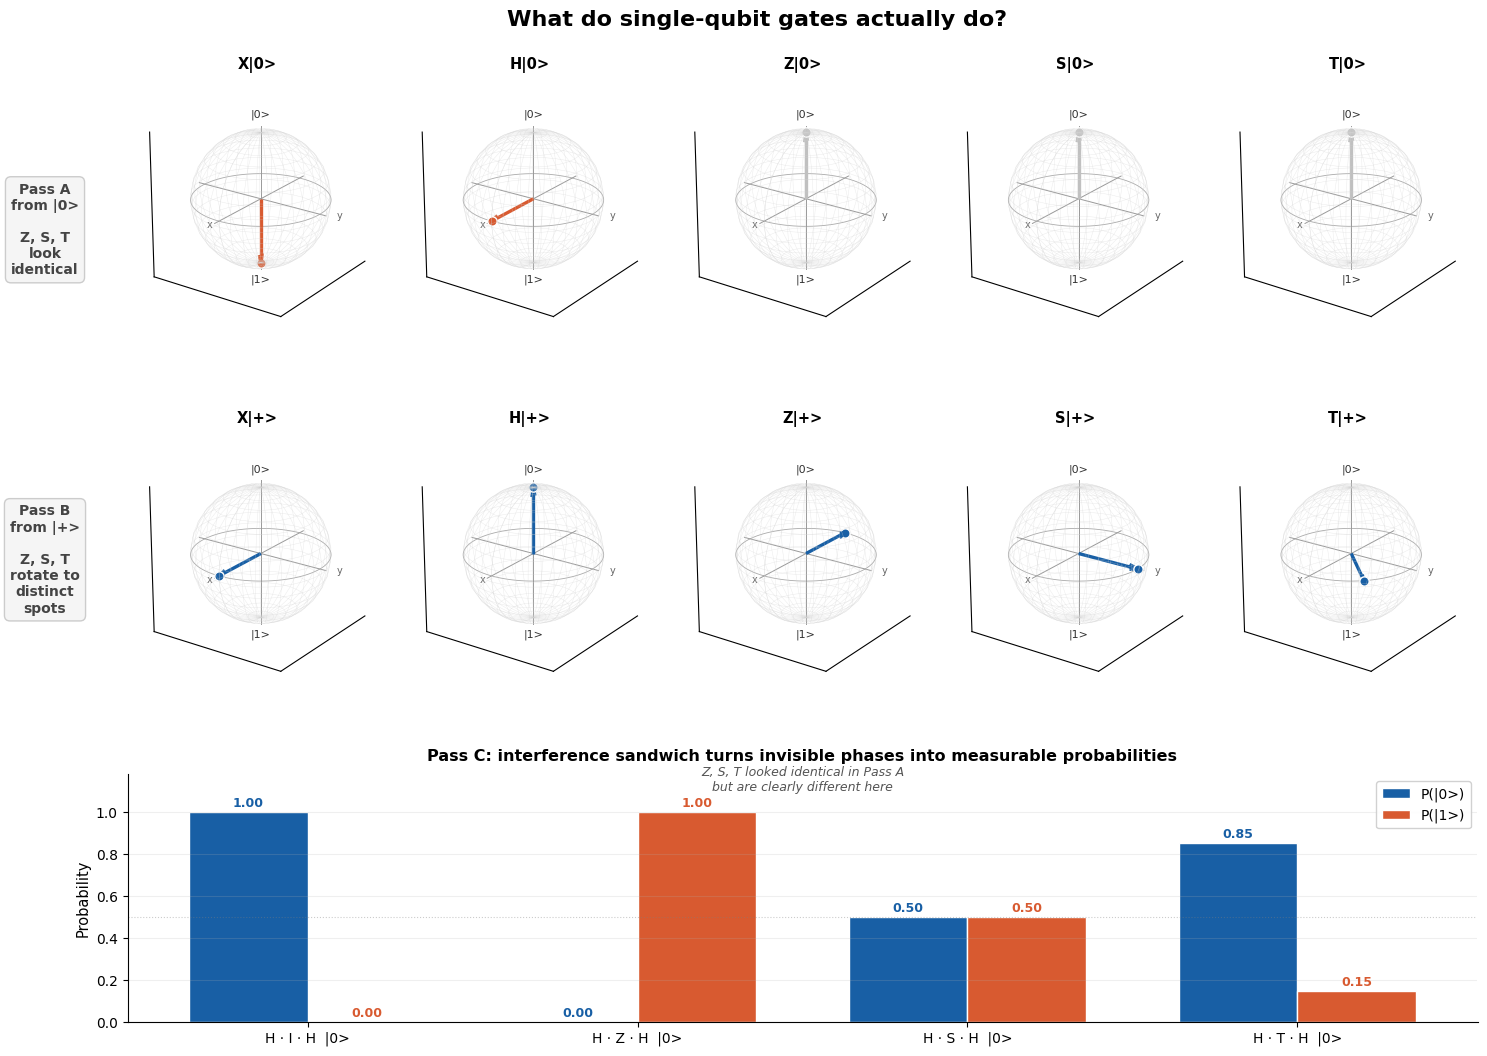

In [ ]:
# What do single-qubit gates actually do?
# One figure, three passes. Run and read top to bottom.

from mpl_toolkits.mplot3d import Axes3D  # registers the 3d projection

# helpers

def bloch_coords(sv):
    """(x, y, z) Bloch vector from a 1-qubit Statevector."""
    a, b = sv.data[0], sv.data[1]
    return (2 * (a.conjugate() * b).real,
            2 * (a.conjugate() * b).imag,
            abs(a)**2 - abs(b)**2)

def one_gate(sv, gate_name):
    """Apply a single named gate; return sv unchanged when gate_name is None."""
    if gate_name is None:
        return sv
    qc = QuantumCircuit(1)
    getattr(qc, gate_name)(0)
    return sv.evolve(qc)

def draw_bloch(ax, bvec, title, color):
    """Draw a labelled Bloch sphere and highlight the state vector."""
    # wireframe sphere
    u = np.linspace(0, 2 * np.pi, 36)
    v = np.linspace(0, np.pi, 18)
    ax.plot_wireframe(
        np.outer(np.cos(u), np.sin(v)),
        np.outer(np.sin(u), np.sin(v)),
        np.outer(np.ones_like(u), np.cos(v)),
        color="lightgray", linewidth=0.3, alpha=0.5,
    )
    # equator ring
    th = np.linspace(0, 2 * np.pi, 100)
    ax.plot(np.cos(th), np.sin(th), np.zeros_like(th), color="#aaa", lw=0.6)
    # axes
    for seg in [([-1.1,1.1],[0,0],[0,0]),([0,0],[-1.1,1.1],[0,0]),([0,0],[0,0],[-1.1,1.1])]:
        ax.plot(*seg, color="#999", lw=0.7)
    ax.text(1.28, 0,    0,     "x",   fontsize=7, color="#666")
    ax.text(0,    1.28, 0,     "y",   fontsize=7, color="#666")
    ax.text(0,    0,    1.22,  "|0>", fontsize=8, color="#333", ha="center")
    ax.text(0,    0,   -1.32,  "|1>", fontsize=8, color="#333", ha="center")
    # state vector
    bx, by, bz = bvec
    ax.quiver(0, 0, 0, bx, by, bz, color=color, lw=2.4, arrow_length_ratio=0.14)
    ax.scatter([bx], [by], [bz], color=color, s=45, edgecolor="white", lw=1, zorder=5)
    # cosmetics
    ax.set(xlim=(-1.1,1.1), ylim=(-1.1,1.1), zlim=(-1.1,1.1))
    ax.set_box_aspect([1,1,1])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_title(title, fontsize=10.5, pad=0, fontweight="bold")
    ax.view_init(elev=22, azim=35)
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.fill = False
        pane.set_edgecolor("none")

# data

GATES = [("X","x"), ("H","h"), ("Z","z"), ("S","s"), ("T","t")]
zero  = Statevector([1, 0])
plus  = one_gate(zero, "h")          # |+> = H|0>

# figure

fig = plt.figure(figsize=(15, 11))
gs  = fig.add_gridspec(
    3, 5,
    height_ratios=[1, 1, 0.9],
    hspace=0.30, wspace=0.05,
    left=0.08, right=0.98, top=0.93, bottom=0.06,
)
fig.suptitle("What do single-qubit gates actually do?",
             fontsize=16, fontweight="bold", y=0.98)

# Pass A: gates on |0>, phase gates unchanged, shown gray
for col, (name, g) in enumerate(GATES):
    ax  = fig.add_subplot(gs[0, col], projection="3d")
    bv  = bloch_coords(one_gate(zero, g))
    moved = np.linalg.norm(np.array(bv) - [0, 0, 1]) > 1e-6
    draw_bloch(ax, bv, f"{name}|0>", "#D85A30" if moved else "#c0c0c0")

# Pass B: gates on |+>, all five now visibly different
for col, (name, g) in enumerate(GATES):
    ax = fig.add_subplot(gs[1, col], projection="3d")
    draw_bloch(ax, bloch_coords(one_gate(plus, g)), f"{name}|+>", "#185FA5")

# row guide labels
label_kw = dict(fontsize=10, ha="center", va="center", fontweight="bold", color="#444",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5", edgecolor="#ccc"))
fig.text(0.025, 0.78, "Pass A\nfrom |0>\n\nZ, S, T\nlook\nidentical",  **label_kw)
fig.text(0.025, 0.48, "Pass B\nfrom |+>\n\nZ, S, T\nrotate to\ndistinct\nspots",   **label_kw)

# Pass C: interference sandwich H gate H on |0>
ax_c = fig.add_subplot(gs[2, :])
sandwich = [("I", None), ("Z","z"), ("S","s"), ("T","t")]
p0s, p1s = [], []
for _, g in sandwich:
    qc = QuantumCircuit(1)
    qc.h(0)
    if g: getattr(qc, g)(0)
    qc.h(0)
    p0, p1 = zero.evolve(qc).probabilities()
    p0s.append(p0); p1s.append(p1)

xp = np.arange(len(sandwich))
w  = 0.36
ax_c.bar(xp - w/2, p0s, w, label="P(|0>)", color="#185FA5", edgecolor="white")
ax_c.bar(xp + w/2, p1s, w, label="P(|1>)", color="#D85A30", edgecolor="white")
ax_c.set_xticks(xp)
ax_c.set_xticklabels([f"H · {n} · H  |0>" for n, _ in sandwich], fontsize=10)
ax_c.set_ylim(0, 1.18)
ax_c.set_ylabel("Probability", fontsize=10.5)
ax_c.set_title(
    "Pass C: interference sandwich turns invisible phases into measurable probabilities",
    fontsize=11.5, pad=10, fontweight="bold",
)
ax_c.axhline(0.5, color="gray", linestyle=":", alpha=0.4, lw=0.8)
ax_c.legend(loc="upper right", fontsize=10, framealpha=0.9)
ax_c.grid(alpha=0.2, axis="y")
ax_c.spines["top"].set_visible(False)
ax_c.spines["right"].set_visible(False)
for i, (p0, p1) in enumerate(zip(p0s, p1s)):
    ax_c.text(i - w/2, p0 + 0.025, f"{p0:.2f}", ha="center", fontsize=9,
              fontweight="bold", color="#185FA5")
    ax_c.text(i + w/2, p1 + 0.025, f"{p1:.2f}", ha="center", fontsize=9,
              fontweight="bold", color="#D85A30")
ax_c.annotate(
    "Z, S, T looked identical in Pass A\nbut are clearly different here",
    xy=(1.5, 1.10), ha="center", fontsize=9, style="italic", color="#555",
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


**Step 2:** Let's continue with single-qubit gates.
Single-qubit gates are expressive, but on their own they can't create *correlations* between qubits. For that we need a **two-qubit gate**. The workhorse is **CNOT** (controlled-NOT):

- Look at the **control qubit**.
- If it's 1, flip the **target qubit**.
- If it's 0, leave the target alone.

That's it. But this single rule is how all entanglement, all two-qubit logic, and ultimately all quantum speedups get built. The cell below runs CNOT on every possible classical input ($|00\rangle, |01\rangle, |10\rangle, |11\rangle$) so you can read the truth table directly from Qiskit output.

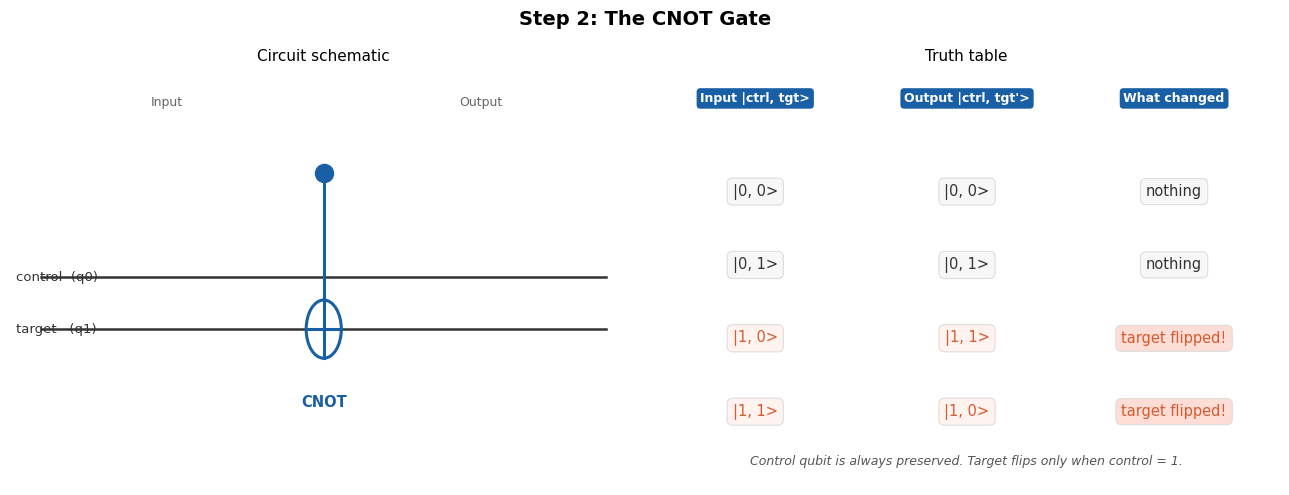

In [ ]:
# The CNOT gate, circuit schematic + truth table

fig, (ax_circ, ax_tbl) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Step 2: The CNOT Gate", fontsize=14, fontweight="bold")

# left panel: hand-drawn circuit schematic
ax_circ.set_xlim(0, 10); ax_circ.set_ylim(-0.5, 3.5); ax_circ.axis("off")
ax_circ.set_title("Circuit schematic", fontsize=11)

for y, label in [(1.5, "control  (q0)"), (1.0, "target   (q1)")]:
    ax_circ.plot([0.5, 9.5], [y, y], color="#333", lw=1.8)
    ax_circ.text(0.1, y, label, fontsize=9.5, va="center", ha="left", color="#333")

cx, cy_ctrl, cy_tgt = 5.0, 2.5, 1.0
ax_circ.plot(cx, cy_ctrl, "o", color="#185FA5", markersize=13, zorder=5)
ax_circ.plot([cx, cx], [cy_ctrl, cy_tgt], color="#185FA5", lw=2.2)
circle = plt.Circle((cx, cy_tgt), 0.28, color="white",
                     ec="#185FA5", lw=2.2, zorder=4)
ax_circ.add_patch(circle)
ax_circ.plot([cx-0.28, cx+0.28], [cy_tgt, cy_tgt], color="#185FA5", lw=2.2, zorder=5)
ax_circ.plot([cx, cx], [cy_tgt-0.28, cy_tgt+0.28], color="#185FA5", lw=2.2, zorder=5)
ax_circ.text(cx, 0.25, "CNOT", fontsize=10.5, ha="center",
             color="#185FA5", fontweight="bold")
ax_circ.text(2.5, 3.15, "Input",  fontsize=9, ha="center", color="#666")
ax_circ.text(7.5, 3.15, "Output", fontsize=9, ha="center", color="#666")

# right panel: truth table as colored cells
ax_tbl.set_xlim(0, 4); ax_tbl.set_ylim(-0.5, 4.6); ax_tbl.axis("off")
ax_tbl.set_title("Truth table", fontsize=11)

headers = ["Input |ctrl, tgt>", "Output |ctrl, tgt'>", "What changed"]
rows = [
    ("|0, 0>", "|0, 0>", "nothing",        False),
    ("|0, 1>", "|0, 1>", "nothing",        False),
    ("|1, 0>", "|1, 1>", "target flipped!", True),
    ("|1, 1>", "|1, 0>", "target flipped!", True),
]
col_x = [0.03, 1.38, 2.70]
col_w = [1.25, 1.25, 1.25]

for j, h in enumerate(headers):
    ax_tbl.text(col_x[j] + col_w[j]/2, 4.2, h, fontsize=9, ha="center",
                fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="#185FA5", edgecolor="none"))

for i, (inp, out, note, flipped) in enumerate(rows):
    y = 3.1 - i * 0.9
    bg = "#FFF3EF" if flipped else "#F7F7F7"
    fc_note = "#FDDDD5" if flipped else "#F7F7F7"
    col_txt = "#D85A30" if flipped else "#333"
    for j, val in enumerate([inp, out, note]):
        fc = fc_note if j == 2 else bg
        ax_tbl.text(col_x[j] + col_w[j]/2, y, val,
                    fontsize=10.5, ha="center", va="center", color=col_txt,
                    bbox=dict(boxstyle="round,pad=0.38",
                              facecolor=fc, edgecolor="#ddd", lw=0.8))

ax_tbl.text(2.0, -0.25,
            "Control qubit is always preserved. Target flips only when control = 1.",
            fontsize=9, ha="center", style="italic", color="#555")

plt.tight_layout()
plt.show()

**Step 3:** Tracking state through a pipeline
A real circuit is a sequence of gates. The way to debug a pipeline is to print intermediate values at each stage, and the same idea works here: after every gate, print the probability of each basis state. Watching the probabilities shift is the clearest way to build intuition for what a circuit does.

Below we apply a sequence of gates and show the state after each one. The four columns are the probabilities of measuring each two-qubit outcome: $|00\rangle$, $|01\rangle$, $|10\rangle$, $|11\rangle$.

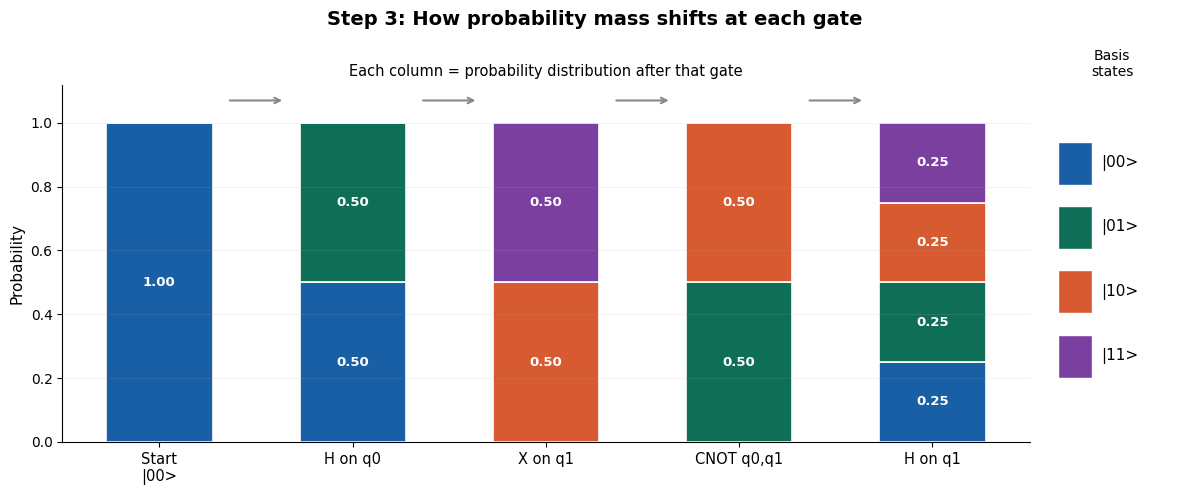

In [ ]:
# Tracking probability through a multi-gate pipeline

def apply_step(state, gate_name, wires):
    qc = QuantumCircuit(2)
    getattr(qc, gate_name)(*wires)
    return state.evolve(qc)

pipeline = [
    ("H on q0",    "h",  [0]),
    ("X on q1",    "x",  [1]),
    ("CNOT q0,q1", "cx", [0, 1]),
    ("H on q1",    "h",  [1]),
]

state = Statevector.from_label("00")
steps = ["Start\n|00>"]
BASIS = ["00", "01", "10", "11"]
history = [{"00": 1.0, "01": 0.0, "10": 0.0, "11": 0.0}]

for label, gate_name, wires in pipeline:
    state = apply_step(state, gate_name, wires)
    p = state.probabilities_dict()
    history.append({s: p.get(s, 0) for s in BASIS})
    steps.append(label)

# stacked bar chart
COLORS = {"00": "#185FA5", "01": "#0F6E56", "10": "#D85A30", "11": "#7B3FA0"}

fig, (ax, ax_leg) = plt.subplots(
    1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [5, 0.7]}
)
fig.suptitle("Step 3: How probability mass shifts at each gate",
             fontsize=14, fontweight="bold")

x = np.arange(len(steps))
bottoms = np.zeros(len(steps))
for s in BASIS:
    vals = np.array([h[s] for h in history])
    ax.bar(x, vals, 0.55, bottom=bottoms, color=COLORS[s],
           edgecolor="white", lw=1.2)
    for xi, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0.06:
            ax.text(xi, b + v/2, f"{v:.2f}", ha="center", va="center",
                    fontsize=9.5, fontweight="bold", color="white")
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(steps, fontsize=10.5)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Probability", fontsize=11)
ax.set_title("Each column = probability distribution after that gate", fontsize=10.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.15, axis="y")

for i in range(1, len(steps)):
    ax.annotate("", xy=(i - 0.35, 1.07), xytext=(i - 0.65, 1.07),
                arrowprops=dict(arrowstyle="->", color="#888", lw=1.5))

# legend panel
ax_leg.axis("off")
ax_leg.set_title("Basis\nstates", fontsize=10)
for i, s in enumerate(BASIS):
    ax_leg.add_patch(plt.Rectangle((0.1, 0.72 - i*0.18), 0.25, 0.12,
                                    facecolor=COLORS[s], edgecolor="white"))
    ax_leg.text(0.42, 0.78 - i*0.18, f"|{s}>", fontsize=11, va="center")
ax_leg.set_xlim(0, 1); ax_leg.set_ylim(0, 1)

plt.tight_layout()
plt.show()

**Step 4:** Product states vs. entangled states
Every two-qubit state you've built so far has been a **product state**: you could describe it by listing each qubit's state independently. A product state like $|0\rangle \otimes |+\rangle$ just means "qubit 0 is in $|0\rangle$, qubit 1 is in $|+\rangle$." Each qubit has its own well-defined state.

**Entangled states** can't be decomposed that way. The canonical example is the Bell state:

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

There is no way to write this as $(\text{qubit 0 state}) \otimes (\text{qubit 1 state})$. The two qubits are correlated: measuring qubit 0 instantly determines qubit 1, even though neither qubit had a definite value before.

**Why this matters:** entanglement is where quantum computing's power comes from. Grover uses it to correlate index qubits with the oracle's phase flip. QAOA uses it to coordinate decisions across nodes. A circuit that only produces product states is classically simulable in polynomial time, so you'd gain nothing from running it on quantum hardware.

**How to tell them apart formally.** Trace out one qubit (ignore it) and look at what's left:

- For a **product state**, the remaining qubit is in a **pure state** (purity = 1). It has its own well-defined state.
- For an **entangled state**, the remaining qubit is **maximally mixed** (purity = 0.5). It looks like a coin flip from that qubit's perspective, with all the structure hiding in the correlation.

Purity is $\text{Tr}(\rho^2)$, where $\rho$ is the reduced density matrix. Pure states have purity 1; maximally mixed 1-qubit states have purity 0.5.

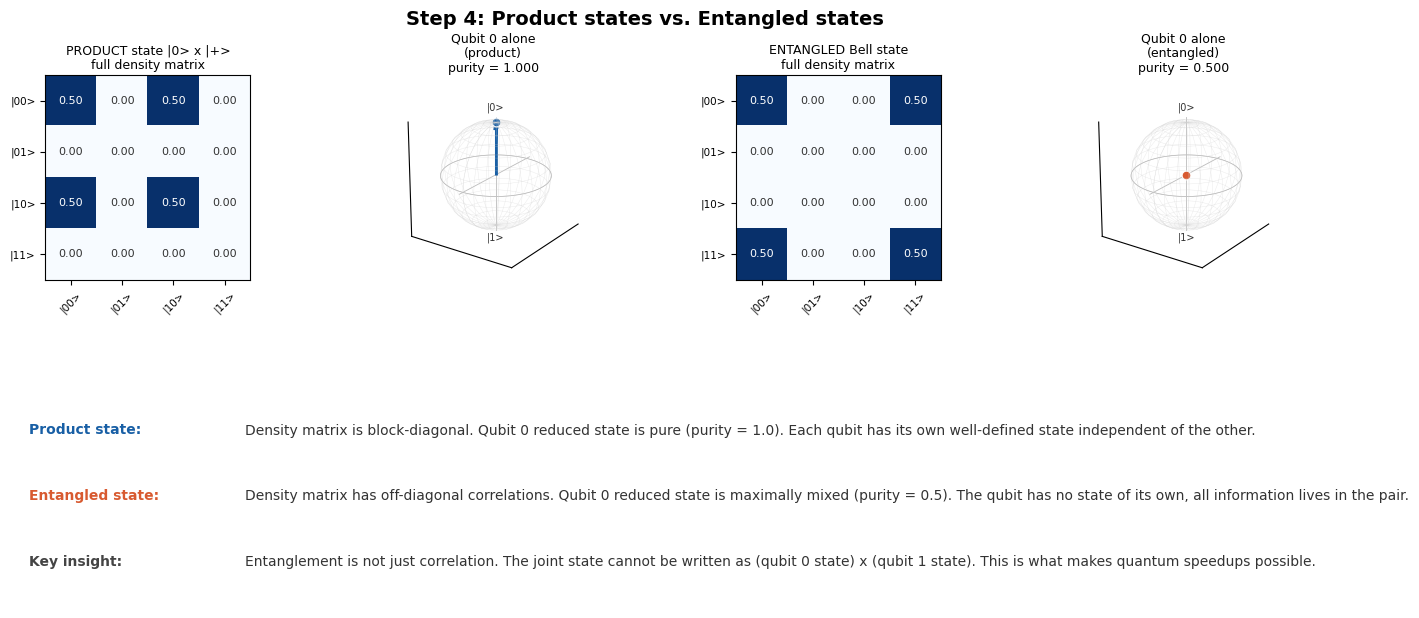

In [ ]:
# Product states vs. entangled states
# Density matrix heatmaps + reduced-state Bloch spheres showing purity

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def dm_heatmap(ax, dm, title):
    """Plot the absolute values of a density matrix as a heatmap."""
    mat = np.abs(dm.data)
    ax.imshow(mat, cmap="Blues", vmin=0, vmax=0.5)
    labels = ["|00>", "|01>", "|10>", "|11>"]
    ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=7.5, rotation=45)
    ax.set_yticks(range(4)); ax.set_yticklabels(labels, fontsize=7.5)
    for i in range(4):
        for j in range(4):
            v = mat[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if v > 0.3 else "#333")
    ax.set_title(title, fontsize=9, pad=4)

def bloch_from_rho(ax, rho, title, purity_val):
    """Draw Bloch sphere for a 1-qubit density matrix; arrow length = purity."""
    u = np.linspace(0, 2*np.pi, 30); v = np.linspace(0, np.pi, 15)
    ax.plot_wireframe(np.outer(np.cos(u), np.sin(v)),
                      np.outer(np.sin(u), np.sin(v)),
                      np.outer(np.ones_like(u), np.cos(v)),
                      color="lightgray", lw=0.3, alpha=0.5)
    th = np.linspace(0, 2*np.pi, 80)
    ax.plot(np.cos(th), np.sin(th), np.zeros_like(th), color="#aaa", lw=0.5)
    ax.plot([-1.1,1.1],[0,0],[0,0], color="#bbb", lw=0.6)
    ax.plot([0,0],[0,0],[-1.1,1.1], color="#bbb", lw=0.6)
    ax.text(0, 0, 1.22,  "|0>", fontsize=7, ha="center", color="#333")
    ax.text(0, 0, -1.32, "|1>", fontsize=7, ha="center", color="#333")
    bx = 2 * rho[0, 1].real
    by = 2 * rho[0, 1].imag
    bz = rho[0, 0].real - rho[1, 1].real
    color = "#185FA5" if purity_val > 0.9 else "#D85A30"
    ax.quiver(0, 0, 0, bx, by, bz, color=color, lw=2.2, arrow_length_ratio=0.14)
    ax.scatter([bx], [by], [bz], color=color, s=40,
               edgecolor="white", lw=0.8, zorder=5)
    ax.set_xlim(-1.1,1.1); ax.set_ylim(-1.1,1.1); ax.set_zlim(-1.1,1.1)
    ax.set_box_aspect([1,1,1])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.view_init(elev=22, azim=35)
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.fill = False; pane.set_edgecolor("none")
    ax.set_title(f"{title}\npurity = {purity_val:.3f}", fontsize=9, pad=0)

def purity(rho):
    return float(np.real(np.trace(rho.data @ rho.data)))

# Build the two states
qc_prod = QuantumCircuit(2); qc_prod.h(1)
dm_prod  = DensityMatrix(Statevector.from_instruction(qc_prod))
rho0_prod = partial_trace(dm_prod, [1])
pur_prod  = purity(rho0_prod)

qc_bell = QuantumCircuit(2); qc_bell.h(0); qc_bell.cx(0, 1)
dm_bell  = DensityMatrix(Statevector.from_instruction(qc_bell))
rho0_bell = partial_trace(dm_bell, [1])
pur_bell  = purity(rho0_bell)

# Figure layout: 2 rows x 4 cols
fig = plt.figure(figsize=(14, 6.5))
fig.suptitle("Step 4: Product states vs. Entangled states",
             fontsize=14, fontweight="bold")
gs = fig.add_gridspec(2, 4, hspace=0.6, wspace=0.45,
                      left=0.06, right=0.97, top=0.88, bottom=0.06)

# Row 0: heatmaps + Bloch spheres
ax_dm_prod  = fig.add_subplot(gs[0, 0])
ax_bl_prod  = fig.add_subplot(gs[0, 1], projection="3d")
ax_dm_bell  = fig.add_subplot(gs[0, 2])
ax_bl_bell  = fig.add_subplot(gs[0, 3], projection="3d")

dm_heatmap(ax_dm_prod, dm_prod,  "PRODUCT state |0> x |+>\nfull density matrix")
dm_heatmap(ax_dm_bell, dm_bell,  "ENTANGLED Bell state\nfull density matrix")
bloch_from_rho(ax_bl_prod, rho0_prod.data, "Qubit 0 alone\n(product)",   pur_prod)
bloch_from_rho(ax_bl_bell, rho0_bell.data, "Qubit 0 alone\n(entangled)", pur_bell)

# Row 1: narrative key
ax_txt = fig.add_subplot(gs[1, :])
ax_txt.axis("off")
lines = [
    ("Product state:",
     f"Density matrix is block-diagonal. Qubit 0 reduced state is pure (purity = {pur_prod:.1f}). "
     "Each qubit has its own well-defined state independent of the other.",
     "#185FA5"),
    ("Entangled state:",
     f"Density matrix has off-diagonal correlations. Qubit 0 reduced state is maximally mixed "
     f"(purity = {pur_bell:.1f}). The qubit has no state of its own, all information lives in the pair.",
     "#D85A30"),
    ("Key insight:",
     "Entanglement is not just correlation. The joint state cannot be written as "
     "(qubit 0 state) x (qubit 1 state). This is what makes quantum speedups possible.",
     "#444"),
]
for i, (bold, rest, col) in enumerate(lines):
    ax_txt.text(0.00, 0.90 - i*0.32, bold, fontsize=10, fontweight="bold",
                color=col, va="top", transform=ax_txt.transAxes)
    ax_txt.text(0.17, 0.90 - i*0.32, rest, fontsize=10, color="#333",
                va="top", transform=ax_txt.transAxes)

plt.show()

**Step 5:** Now it is time to build our own circuit!

Your circuit:
     ┌───┐     ┌───┐┌─┐
q_0: ┤ H ├──■──┤ H ├┤M├
     ├───┤┌─┴─┐└┬─┬┘└╥┘
q_1: ┤ H ├┤ X ├─┤M├──╫─
     └───┘└───┘ └╥┘  ║ 
c: 2/════════════╩═══╩═
                 1   0 

Results (4000 shots):
  |00>:  1991 ( 49.8%)  ########################
  |01>:     0 (  0.0%)  
  |10>:  2009 ( 50.2%)  #########################
  |11>:     0 (  0.0%)  


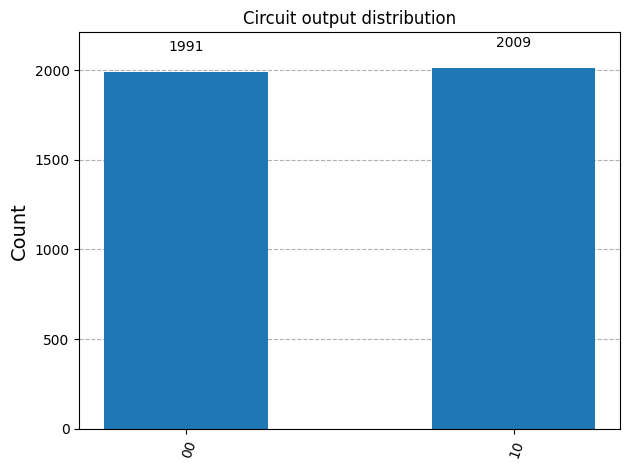

In [ ]:
# Build your own circuit
# Change the gates below and re-run to see what happens.

qc = QuantumCircuit(2, 2)

qc.h(0)        # Hadamard on qubit 0
qc.h(1)        # Hadamard on qubit 1
qc.cx(0, 1)    # CNOT
qc.h(0)        # Another Hadamard

qc.measure([0, 1], [0, 1])

print("Your circuit:")
print(qc.draw("text"))

counts = simulator.run(qc, shots=4000).result().get_counts()
total = sum(counts.values())

print()
print("Results (4000 shots):")
for state in ["00", "01", "10", "11"]:
    count = counts.get(state, 0)
    bar = "#" * (count // 80)
    print(f"  |{state}>: {count:5d} ({count/total*100:5.1f}%)  {bar}")

fig = plot_histogram(counts, title="Circuit output distribution")
display(fig)
plt.close()

# **Milestone 4: Quantum Search (Grover's Algorithm)**

Imagine you are a data scientist with an unsorted dataset of N records. You need to
find the one record matching a specific condition. No index. No sort key.
Just a raw lookup.
| | Classical | Grover |
|---|---|---|
| Strategy | Check each record one by one | Constructive interference on the target |
| Steps | O(N) | O(sqrt N) |
| 1 million records | ~500,000 checks | ~785 checks |
| 1 trillion records | ~500 billion checks | ~785,000 checks |

The speedup grows with the dataset. Grover is provably optimal for unstructured search.

This milestone builds Grover in four steps, then shows how to translate a real data science predicate into an oracle.

### Key Terms for Milestone 4

| Term | Plain-English Definition |
|------|--------------------------|
| **Amplitude amplification** | A quantum technique that increases the probability of a desired outcome |
| **Oracle** | A quantum gate that "marks" the target state by flipping its phase |
| **Diffuser** | A quantum gate that amplifies the marked state's probability |
| **Phase kickback** | How a phase flip on one qubit can propagate through entanglement |
| **Over-rotation** | Running Grover too many iterations, causing probability to drop back down |

**Step 1:** Let's visualize the speedup

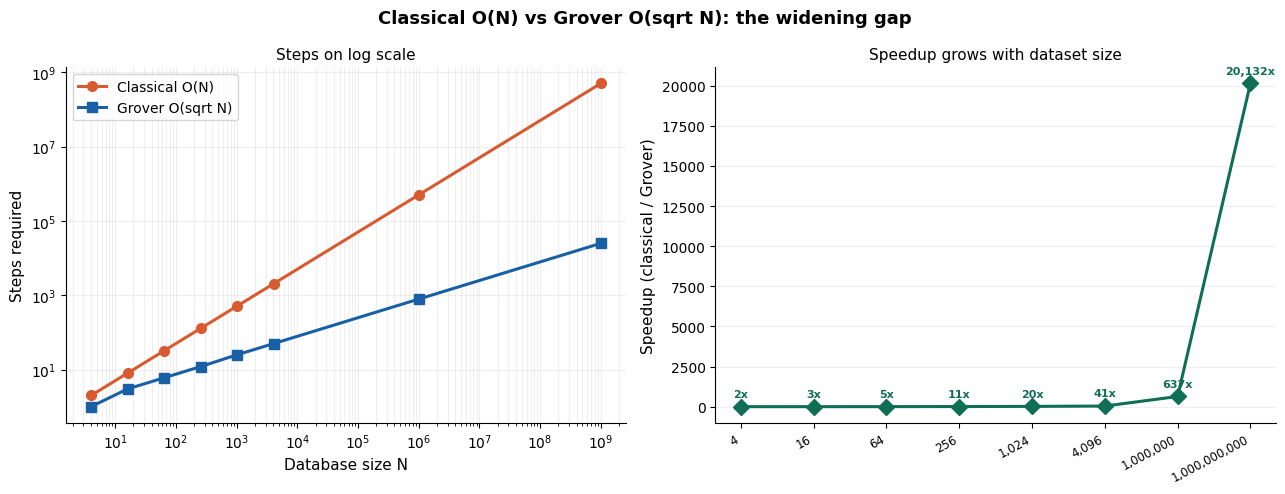

In [ ]:
import math

sizes    = [4, 16, 64, 256, 1_024, 4_096, 1_000_000, 1_000_000_000]
cl_steps = [N // 2                               for N in sizes]
qu_steps = [max(1, int(math.pi/4 * math.sqrt(N))) for N in sizes]
speedups  = [c/q for c, q in zip(cl_steps, qu_steps)]

fig, (ax_log, ax_ratio) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Classical O(N) vs Grover O(sqrt N): the widening gap",
             fontsize=13, fontweight="bold")

ax_log.loglog(sizes, cl_steps, "o-", color="#D85A30", lw=2.2,
              markersize=7, label="Classical O(N)")
ax_log.loglog(sizes, qu_steps, "s-", color="#185FA5", lw=2.2,
              markersize=7, label="Grover O(sqrt N)")
ax_log.set_xlabel("Database size N", fontsize=11)
ax_log.set_ylabel("Steps required", fontsize=11)
ax_log.set_title("Steps on log scale", fontsize=11)
ax_log.legend(fontsize=10)
ax_log.grid(alpha=0.2, which="both")
ax_log.spines["top"].set_visible(False); ax_log.spines["right"].set_visible(False)

ax_ratio.plot(range(len(sizes)), speedups, "D-", color="#0F6E56", lw=2.2, markersize=8)
ax_ratio.set_xticks(range(len(sizes)))
ax_ratio.set_xticklabels([f"{N:,}" for N in sizes], rotation=28, ha="right", fontsize=8.5)
ax_ratio.set_ylabel("Speedup (classical / Grover)", fontsize=11)
ax_ratio.set_title("Speedup grows with dataset size", fontsize=11)
ax_ratio.grid(alpha=0.2, axis="y")
ax_ratio.spines["top"].set_visible(False); ax_ratio.spines["right"].set_visible(False)
for i, s in enumerate(speedups):
    ax_ratio.text(i, s + max(speedups)*0.03, f"{s:,.0f}x",
                  ha="center", fontsize=8, color="#0F6E56", fontweight="bold")

plt.tight_layout()
plt.show()


**Step 2:** Three ingredients, one loop

Before writing any circuit, build the mental model. Grover is not a filter
that discards wrong answers. It is a rotation in a 2D space that amplifies the
target amplitude a little each iteration.

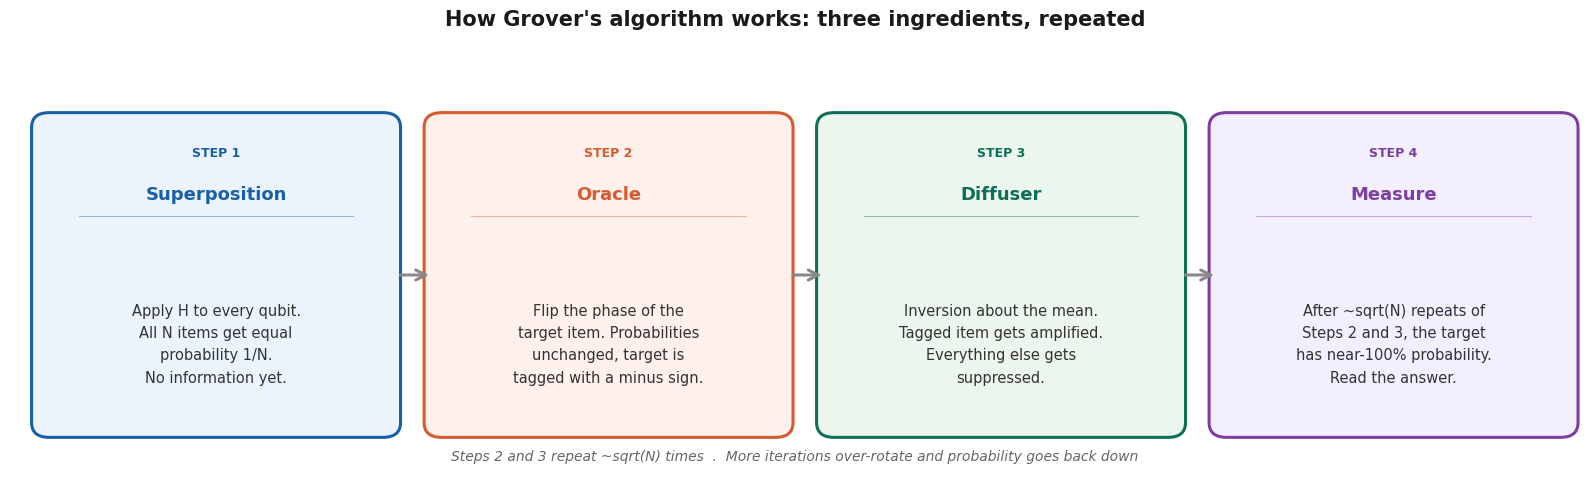

In [ ]:
# STEP 2: Grover algorithm flow diagram
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(16, 5))
ax.set_xlim(0, 16); ax.set_ylim(0, 5); ax.axis('off')
fig.patch.set_facecolor('white')
fig.suptitle("How Grover's algorithm works: three ingredients, repeated",
             fontsize=15, fontweight='bold', y=0.97, color='#1a1a1a')

boxes = [
    (0.4,  "STEP 1", "Superposition",
     "Apply H to every qubit.\nAll N items get equal\nprobability 1/N.\nNo information yet.",
     '#EBF4FD', '#185FA5'),
    (4.4,  "STEP 2", "Oracle",
     "Flip the phase of the\ntarget item. Probabilities\nunchanged, target is\ntagged with a minus sign.",
     '#FEF0EB', '#D85A30'),
    (8.4,  "STEP 3", "Diffuser",
     "Inversion about the mean.\nTagged item gets amplified.\nEverything else gets\nsuppressed.",
     '#EBF6EC', '#0F6E56'),
    (12.4, "STEP 4", "Measure",
     "After ~sqrt(N) repeats of\nSteps 2 and 3, the target\nhas near-100% probability.\nRead the answer.",
     '#F3EFFE', '#7B3FA0'),
]

BOX_W, BOX_H, BOX_Y = 3.4, 3.6, 0.7

for x, step_label, title, body, fc, ec in boxes:
    ax.add_patch(FancyBboxPatch((x, BOX_Y), BOX_W, BOX_H,
                                boxstyle='round,pad=0.18',
                                facecolor=fc, edgecolor=ec, linewidth=2.2, zorder=2))
    ax.text(x + BOX_W/2, BOX_Y + BOX_H - 0.32, step_label,
            ha='center', va='center', fontsize=9, fontweight='bold', color=ec, zorder=3)
    ax.text(x + BOX_W/2, BOX_Y + BOX_H - 0.82, title,
            ha='center', va='center', fontsize=13, fontweight='bold', color=ec, zorder=3)
    ax.plot([x + 0.3, x + BOX_W - 0.3],
            [BOX_Y + BOX_H - 1.08, BOX_Y + BOX_H - 1.08],
            color=ec, lw=0.8, alpha=0.4, zorder=3)
    ax.text(x + BOX_W/2, BOX_Y + 0.95, body,
            ha='center', va='center', fontsize=10.5, color='#333',
            linespacing=1.6, zorder=3)

for x_arrow in [3.9, 7.9, 11.9]:
    ax.annotate('', xy=(x_arrow + 0.4, BOX_Y + BOX_H/2),
                    xytext=(x_arrow + 0.05, BOX_Y + BOX_H/2),
                arrowprops=dict(arrowstyle='->', color='#888', lw=2.2, mutation_scale=18))

ax.text(8.0, 0.28,
        "Steps 2 and 3 repeat ~sqrt(N) times  .  More iterations over-rotate and probability goes back down",
        ha='center', va='center', fontsize=10, color='#666', style='italic')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Step 3:** The oracle and diffuser in action

The trickiest concept: how does a phase flip (which does not change any
probability) eventually produce a probability boost? This cell shows the
amplitudes at each stage for a 4-item database searching for |11>.

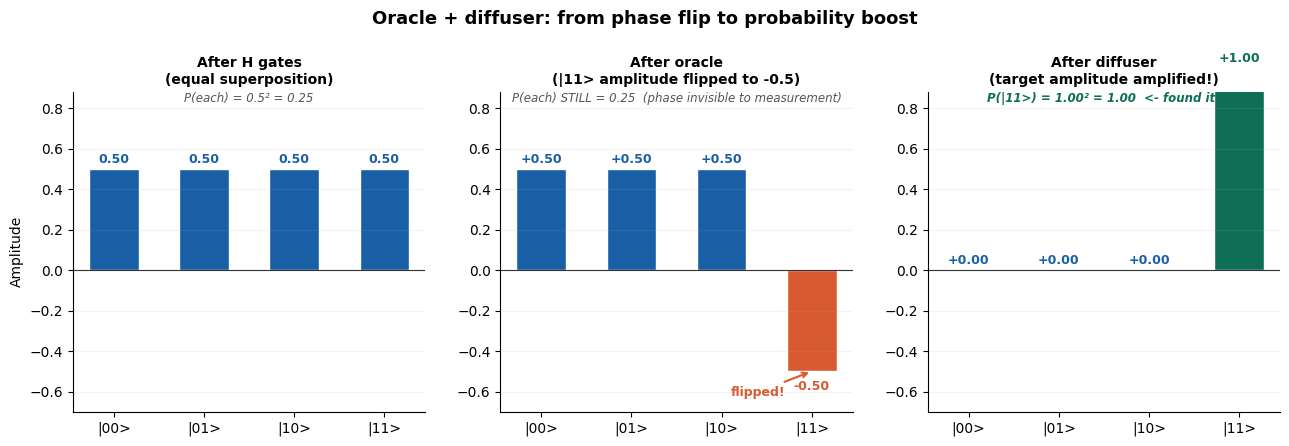

In [ ]:
# Oracle + diffuser shown as amplitude bar charts
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle("Oracle + diffuser: from phase flip to probability boost",
             fontsize=13, fontweight="bold")

states = ["|00>", "|01>", "|10>", "|11>"]
N = 4

# Panel 1: after H gates, equal superposition
amps_h = [0.5] * 4
axes[0].bar(states, amps_h, color="#185FA5", edgecolor="white", width=0.55)
axes[0].set_ylim(-0.7, 0.88); axes[0].axhline(0, color="#333", lw=0.8)
axes[0].set_title("After H gates\n(equal superposition)", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Amplitude", fontsize=10)
for i, v in enumerate(amps_h):
    axes[0].text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=9,
                 color="#185FA5", fontweight="bold")
axes[0].text(1.5, 0.83, "P(each) = 0.5² = 0.25",
             ha="center", fontsize=8.5, style="italic", color="#555")

# Panel 2: after oracle, phase flip on |11>
amps_or = [0.5, 0.5, 0.5, -0.5]
colors_or = ["#185FA5"] * 3 + ["#D85A30"]
axes[1].bar(states, amps_or, color=colors_or, edgecolor="white", width=0.55)
axes[1].set_ylim(-0.7, 0.88); axes[1].axhline(0, color="#333", lw=0.8)
axes[1].set_title("After oracle\n(|11> amplitude flipped to -0.5)", fontsize=10, fontweight="bold")
for i, v in enumerate(amps_or):
    off = 0.03 if v > 0 else -0.09
    axes[1].text(i, v + off, f"{v:+.2f}", ha="center", fontsize=9, fontweight="bold",
                 color="#D85A30" if i == 3 else "#185FA5")
axes[1].text(1.5, 0.83, "P(each) STILL = 0.25  (phase invisible to measurement)",
             ha="center", fontsize=8.5, style="italic", color="#555")
axes[1].annotate("flipped!", xy=(3, -0.5), xytext=(2.1, -0.62),
                 arrowprops=dict(arrowstyle="->", color="#D85A30", lw=1.5),
                 fontsize=9, color="#D85A30", fontweight="bold")

# Panel 3: after diffuser, inversion about the mean
mean = sum(amps_or) / N
amps_diff = [2 * mean - a for a in amps_or]
colors_diff = ["#185FA5"] * 3 + ["#0F6E56"]
axes[2].bar(states, amps_diff, color=colors_diff, edgecolor="white", width=0.55)
axes[2].set_ylim(-0.7, 0.88); axes[2].axhline(0, color="#333", lw=0.8)
axes[2].set_title("After diffuser\n(target amplitude amplified!)", fontsize=10, fontweight="bold")
for i, v in enumerate(amps_diff):
    off = 0.03 if v >= 0 else -0.09
    axes[2].text(i, v + off, f"{v:+.2f}", ha="center", fontsize=9, fontweight="bold",
                 color="#0F6E56" if i == 3 else "#185FA5")
p_target = amps_diff[3] ** 2
axes[2].text(1.5, 0.83,
             f"P(|11>) = {amps_diff[3]:.2f}² = {p_target:.2f}  <- found it!",
             ha="center", fontsize=8.5, style="italic", color="#0F6E56", fontweight="bold")

for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.15, axis="y")

plt.tight_layout()
plt.show()


**Step 4:**  Round by round amplification, and the over-rotation trap


Grover is a rotation, not a filter. Run too many iterations and the target
probability goes back down. The optimal number is ~(pi/4) * sqrt(N).

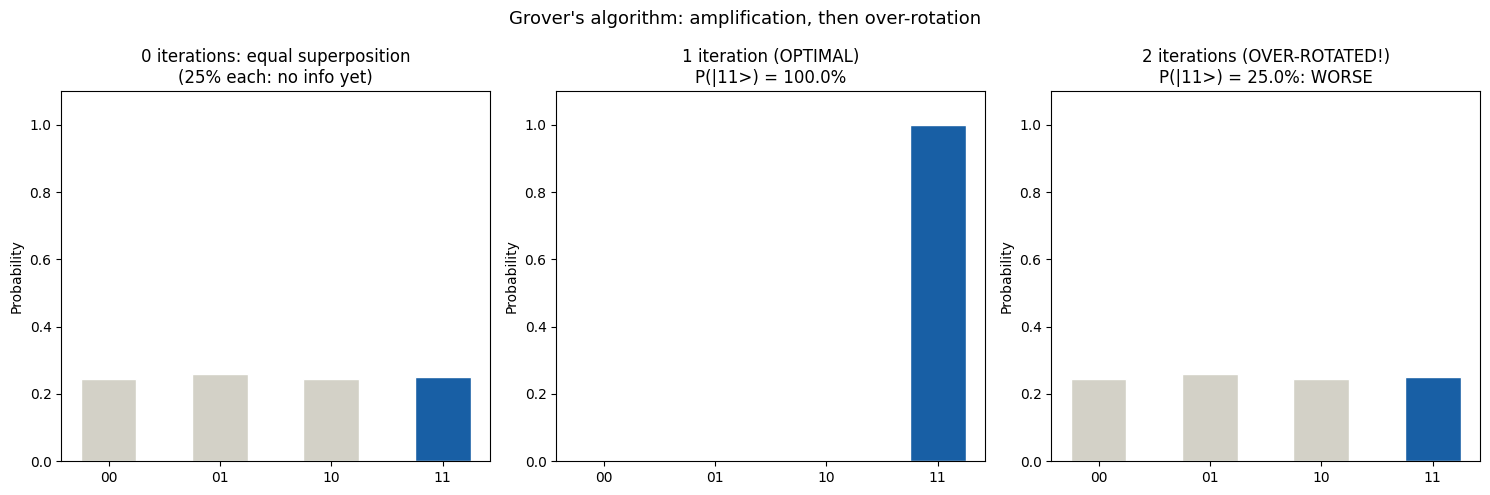

Key insight: Grover is a ROTATION in a 2D subspace, not a monotone amplifier.
The optimal number of iterations is ~(pi/4) * sqrt(N). More iterations OVERSHOOT
and the probability of the target goes DOWN again.


In [ ]:
# Show step by step how Grover amplifies the target
# and what happens when you OVER-rotate (iteration 2: key teaching moment!)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Grover's algorithm: amplification, then over-rotation", fontsize=13)

for idx, n_iters in enumerate([0, 1, 2]):
    qc = QuantumCircuit(2, 2)

    # Step 1: equal superposition (uniform distribution over all 4 items)
    qc.h(0)
    qc.h(1)

    for _ in range(n_iters):
        # Step 2: Oracle, marks |11> by flipping its phase
        qc.cz(0, 1)  # CZ flips phase of |11> only

        # Step 3: Diffuser, inversion about the average
        qc.h([0, 1])
        qc.x([0, 1])
        qc.h(1)
        qc.cx(0, 1)
        qc.h(1)
        qc.x([0, 1])
        qc.h([0, 1])

    qc.measure([0, 1], [0, 1])

    counts = simulator.run(qc, shots=8000).result().get_counts()
    states = ['00', '01', '10', '11']
    probs = [counts.get(s, 0)/8000 for s in states]
    colors = ['#D3D1C7' if s != '11' else '#185FA5' for s in states]

    axes[idx].bar(states, probs, color=colors, edgecolor='white', width=0.5)
    axes[idx].set_ylim(0, 1.1)
    axes[idx].set_ylabel('Probability')

    if n_iters == 0:
        axes[idx].set_title('0 iterations: equal superposition\n(25% each: no info yet)')
    elif n_iters == 1:
        axes[idx].set_title(f'1 iteration (OPTIMAL)\nP(|11>) = {probs[3]:.1%}')
    else:
        axes[idx].set_title(f'2 iterations (OVER-ROTATED!)\nP(|11>) = {probs[3]:.1%}: WORSE')

plt.tight_layout()
plt.show()

print('Key insight: Grover is a ROTATION in a 2D subspace, not a monotone amplifier.')
print('The optimal number of iterations is ~(pi/4) * sqrt(N). More iterations OVERSHOOT')
print('and the probability of the target goes DOWN again.')

**Step 5:** Translating a DS predicate into an oracle

Most tutorials skip the step between "I have a search predicate" and "I have
a Grover oracle." The section below works through a concrete 8-row inventory
table so you can see the translation exactly.

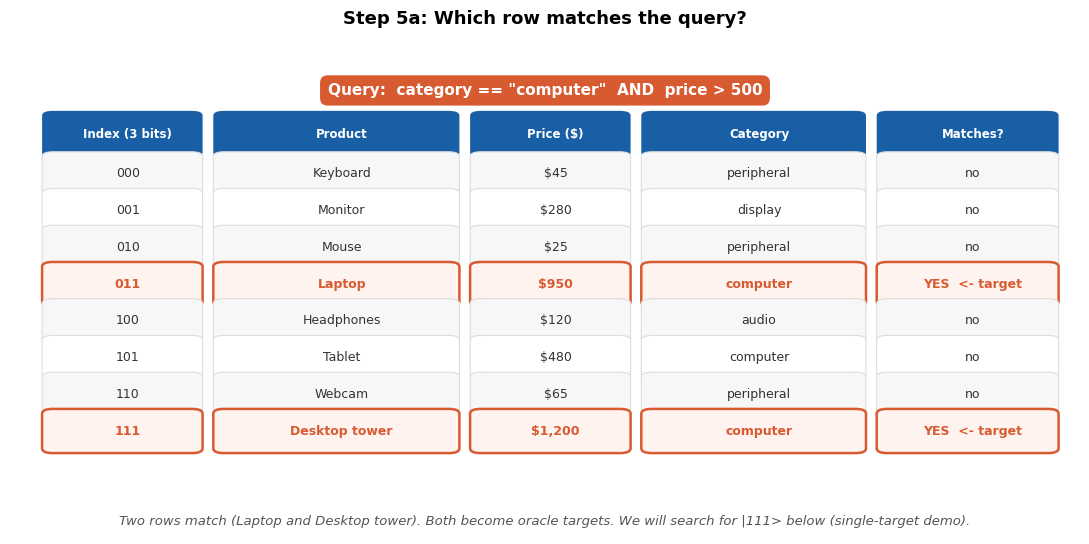

In [ ]:
# STEP 5a: Inventory table , which row matches the query?
from matplotlib.patches import FancyBboxPatch

table_data = [
    ('000', 'Keyboard',       45,   'peripheral'),
    ('001', 'Monitor',       280,   'display'),
    ('010', 'Mouse',          25,   'peripheral'),
    ('011', 'Laptop',        950,   'computer'),
    ('100', 'Headphones',    120,   'audio'),
    ('101', 'Tablet',        480,   'computer'),
    ('110', 'Webcam',         65,   'peripheral'),
    ('111', 'Desktop tower', 1200,  'computer'),
]
query_match = lambda r: r[3] == 'computer' and r[2] > 500

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axis('off')
fig.suptitle("Step 5a: Which row matches the query?",
             fontsize=13, fontweight='bold', y=0.98)

ax.text(0.5, 0.97,
        'Query:  category == "computer"  AND  price > 500',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=11, color='white', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#D85A30', edgecolor='none'))

headers  = ['Index (3 bits)', 'Product', 'Price ($)', 'Category', 'Matches?']
col_x    = [0.04, 0.20, 0.44, 0.60, 0.82]
col_w    = [0.14, 0.22, 0.14, 0.20, 0.16]
row_h    = 0.079

for j, (h, x, w) in enumerate(zip(headers, col_x, col_w)):
    ax.add_patch(FancyBboxPatch((x, 0.82), w - 0.01, 0.08,
                                boxstyle='round,pad=0.01', transform=ax.transAxes,
                                facecolor='#185FA5', edgecolor='none', zorder=2))
    ax.text(x + w/2, 0.86, h, transform=ax.transAxes,
            ha='center', va='center', fontsize=8.5,
            color='white', fontweight='bold', zorder=3)

for i, row in enumerate(table_data):
    y    = 0.82 - (i + 1) * row_h - 0.004
    hit  = query_match(row)
    bg   = '#FFF3EF' if hit else ('#F7F7F7' if i % 2 == 0 else 'white')
    ec_c = '#D85A30' if hit else '#ddd'
    lw   = 1.8 if hit else 0.8
    for x, w in zip(col_x, col_w):
        ax.add_patch(FancyBboxPatch((x, y), w - 0.01, row_h - 0.004,
                                    boxstyle='round,pad=0.01', transform=ax.transAxes,
                                    facecolor=bg, edgecolor=ec_c, lw=lw, zorder=2))
    vals = [row[0], row[1], f'${row[2]:,}', row[3],
            'YES  <- target' if hit else 'no']
    for j, (val, x, w) in enumerate(zip(vals, col_x, col_w)):
        col  = '#D85A30' if hit else '#333'
        fw   = 'bold' if hit else 'normal'
        ax.text(x + w/2, y + row_h/2 - 0.002, val,
                transform=ax.transAxes, ha='center', va='center',
                fontsize=9, color=col, fontweight=fw, zorder=3)

ax.text(0.5, 0.02,
        'Two rows match (Laptop and Desktop tower). Both become oracle targets. '
        'We will search for |111> below (single-target demo).',
        transform=ax.transAxes, ha='center', fontsize=9.5,
        color='#555', style='italic')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

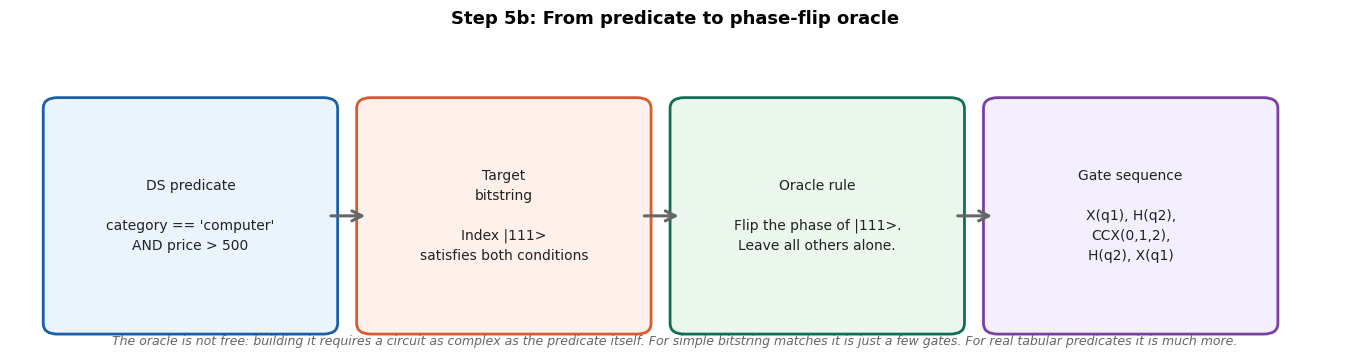

In [ ]:
# STEP 5b: How a DS predicate becomes a phase-flip oracle
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.set_xlim(0, 14); ax.set_ylim(0, 4); ax.axis('off')
fig.suptitle("Step 5b: From predicate to phase-flip oracle",
             fontsize=13, fontweight='bold', y=0.98)

pipeline = [
    ("DS predicate\n\ncategory == 'computer'\nAND price > 500",       '#EBF4FD', '#185FA5'),
    ("Target\nbitstring\n\nIndex |111>\nsatisfies both conditions",   '#FEF0EB', '#D85A30'),
    ("Oracle rule\n\nFlip the phase of |111>.\nLeave all others alone.", '#EBF6EC', '#0F6E56'),
    ("Gate sequence\n\nX(q1), H(q2),\nCCX(0,1,2),\nH(q2), X(q1)",    '#F3EFFE', '#7B3FA0'),
]
bw, bh = 2.8, 3.0
for i, (text, fc, ec) in enumerate(pipeline):
    x = 0.5 + i * (bw + 0.5)
    ax.add_patch(FancyBboxPatch((x, 0.4), bw, bh,
                                boxstyle='round,pad=0.15',
                                facecolor=fc, edgecolor=ec, lw=2))
    ax.text(x + bw/2, 0.4 + bh/2, text,
            ha='center', va='center', fontsize=10,
            color='#222', multialignment='center', linespacing=1.55)
    if i < len(pipeline) - 1:
        ax.annotate('', xy=(x + bw + 0.47, 0.4 + bh/2),
                       xytext=(x + bw + 0.05, 0.4 + bh/2),
                    arrowprops=dict(arrowstyle='->', color='#666', lw=2.2, mutation_scale=18))

ax.text(7.0, 0.15,
        'The oracle is not free: building it requires a circuit as complex as the predicate itself. '
        'For simple bitstring matches it is just a few gates. For real tabular predicates it is much more.',
        ha='center', va='center', fontsize=9, color='#666', style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()


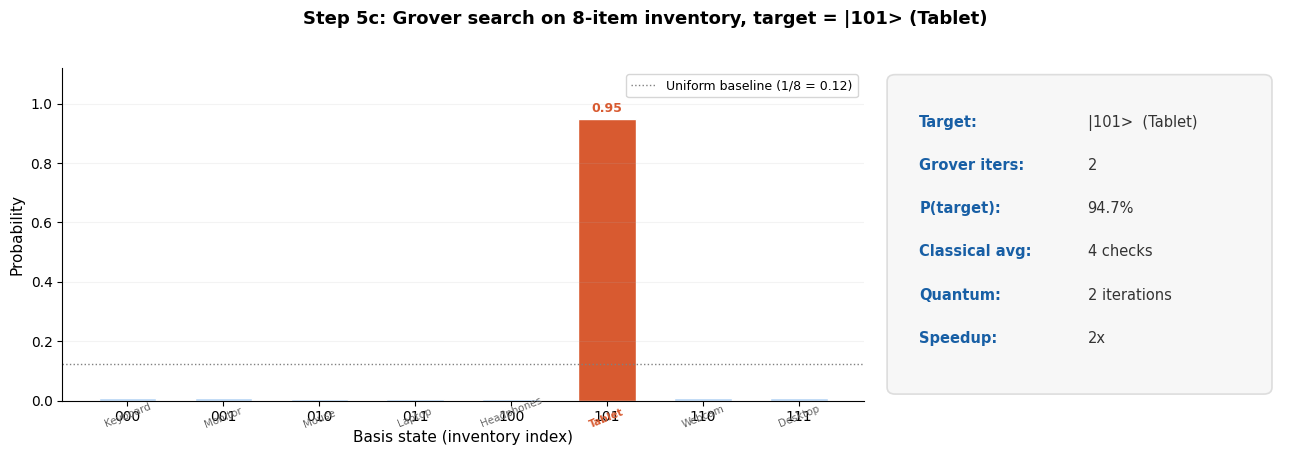

In [ ]:
# STEP 5c: Run Grover on the 8-item inventory and visualise results
import math

n_qubits     = 3
target       = '101'
N            = 2 ** n_qubits
optimal_iters = int(math.pi / 4 * math.sqrt(N))

qc = QuantumCircuit(n_qubits, n_qubits)
qc.h(range(n_qubits))

for _ in range(optimal_iters):
    # Oracle for |101>: X on q1 so target looks like |111>, then CCZ, then un-X
    qc.x(1)
    qc.h(n_qubits - 1)
    qc.ccx(0, 1, n_qubits - 1)
    qc.h(n_qubits - 1)
    qc.x(1)
    # Diffuser: inversion about the average
    qc.h(range(n_qubits))
    qc.x(range(n_qubits))
    qc.h(n_qubits - 1)
    qc.ccx(0, 1, n_qubits - 1)
    qc.h(n_qubits - 1)
    qc.x(range(n_qubits))
    qc.h(range(n_qubits))

qc.measure(range(n_qubits), range(n_qubits))
counts = simulator.run(qc, shots=8000).result().get_counts()
total  = sum(counts.values())

products = {
    '000': 'Keyboard', '001': 'Monitor',  '010': 'Mouse',   '011': 'Laptop',
    '100': 'Headphones','101': 'Tablet',  '110': 'Webcam',  '111': 'Desktop',
}
all_states = [format(i, '03b') for i in range(8)]
probs      = [counts.get(s, 0) / total for s in all_states]
colors     = ['#D85A30' if s == target else '#B5D4F4' for s in all_states]

fig, (ax_bar, ax_info) = plt.subplots(1, 2, figsize=(13, 5),
                                       gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle(f"Step 5c: Grover search on 8-item inventory, target = |{target}> ({products[target]})",
             fontsize=13, fontweight='bold')

ax_bar.bar(all_states, probs, color=colors, edgecolor='white', width=0.6)
ax_bar.set_xlabel('Basis state (inventory index)', fontsize=11)
ax_bar.set_ylabel('Probability', fontsize=11)
ax_bar.set_ylim(0, 1.12)
ax_bar.axhline(1/N, color='gray', lw=1, linestyle=':',
               label=f'Uniform baseline (1/{N} = {1/N:.2f})')
ax_bar.legend(fontsize=9)
ax_bar.spines['top'].set_visible(False); ax_bar.spines['right'].set_visible(False)
ax_bar.grid(alpha=0.15, axis='y')

for i, s in enumerate(all_states):
    ax_bar.text(i, -0.09, products[s], ha='center', fontsize=7.5, rotation=22,
                color='#D85A30' if s == target else '#666',
                fontweight='bold' if s == target else 'normal')
for i, (s, p) in enumerate(zip(all_states, probs)):
    if p > 0.02:
        ax_bar.text(i, p + 0.025, f'{p:.2f}', ha='center', fontsize=9,
                    color='#D85A30' if s == target else '#555', fontweight='bold')

# info panel
ax_info.axis('off')
target_p = counts.get(target, 0) / total
rows_info = [
    ("Target",         f"|{target}>  ({products[target]})"),
    ("Grover iters",   str(optimal_iters)),
    ("P(target)",      f"{target_p:.1%}"),
    ("Classical avg",  f"{N//2} checks"),
    ("Quantum",        f"{optimal_iters} iteration{'s' if optimal_iters!=1 else ''}"),
    ("Speedup",        f"{(N//2)/max(optimal_iters,1):.0f}x"),
]
ax_info.add_patch(FancyBboxPatch((0.04, 0.04), 0.92, 0.92,
                                  boxstyle='round,pad=0.02',
                                  transform=ax_info.transAxes,
                                  facecolor='#F7F7F7', edgecolor='#ddd', lw=1.2))
for i, (label, val) in enumerate(rows_info):
    y = 0.86 - i * 0.13
    ax_info.text(0.10, y, label + ":", fontsize=10.5, fontweight='bold',
                 color='#185FA5', va='top', transform=ax_info.transAxes)
    ax_info.text(0.52, y, val, fontsize=10.5, color='#333',
                 va='top', transform=ax_info.transAxes)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


**Questions:** For a database of 1 million records, how many steps does Grover's algorithm need?
How many does classical search need on average? What is the speedup?

**Ans:**

Suppose your predicate marks **two** rows of the inventory table (say, both computers:
`011` and `111`). Would Grover still work? What would the output distribution look like?
Predict, then modify the oracle to test.

**Ans:**

# **Milestone 5: Quantum Optimization (QAOA)**

Many data science tasks are **combinatorial optimization** problems, meaning finding the best choice from an astronomically large number of options:

- **Feature selection:** 50 features → 2⁵⁰ possible subsets to check
- **Graph clustering:** Partition N nodes into groups to maximize some objective
- **Portfolio optimization:** Choose the best combination of assets

**QAOA** (Quantum Approximate Optimization Algorithm) is the leading near-term quantum approach to these problems. It doesn't guarantee the perfect answer, but it finds *good* ones efficiently. Its structure works for any problem you can write as a mathematical objective.

We'll explore QAOA on the **Max-Cut problem**: given a graph (nodes connected by edges), divide nodes into two groups to maximize the number of edges that "cut" between groups.

Why Max-Cut? Because it's:
- NP-hard (classically intractable at large scale)
- Equivalent to several important DS problems (graph clustering, community detection)
- Simple enough to visualize and verify

### Key Terms for Milestone 5

| Term | Plain-English Definition |
|------|--------------------------|
| **Max-Cut** | Partition graph nodes into 2 groups to maximize cross-group edges |
| **QUBO** | "Quadratic Unconstrained Binary Optimization." A standard way to write optimization problems |
| **Hamiltonian** | A mathematical function that encodes the objective we want to optimize |
| **QAOA circuit** | A parameterized quantum circuit whose output approximates the optimal solution |
| **Approximation ratio** | How close QAOA gets to optimal: 1.0 = perfect, 0.9 = 90% of optimal |

**Step 1:** Let's visualize the Max-Cut problem

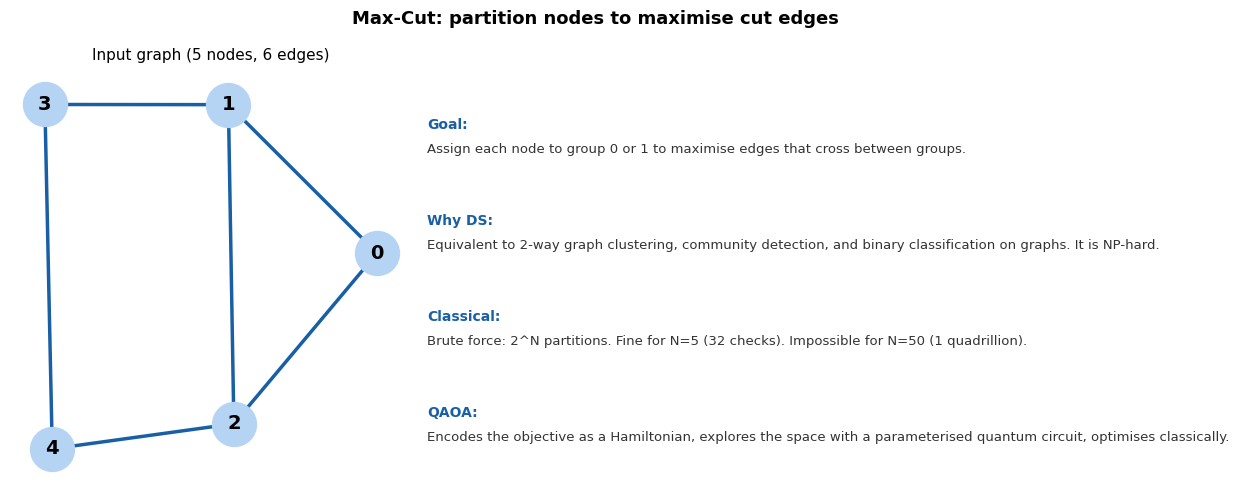

In [ ]:
# Visualize the Max-Cut problem
import networkx as nx

G = nx.Graph()
G.add_nodes_from([0, 1, 2, 3, 4])
G.add_edges_from([(0,1), (0,2), (1,2), (1,3), (2,4), (3,4)])
pos = nx.spring_layout(G, seed=SEED)

fig, (ax_g, ax_txt) = plt.subplots(1, 2, figsize=(12, 5),
                                    gridspec_kw={"width_ratios": [1.2, 1]})
fig.suptitle("Max-Cut: partition nodes to maximise cut edges",
             fontsize=13, fontweight="bold")

nx.draw(G, pos, ax=ax_g, with_labels=True, node_color="#B5D4F4",
        node_size=1000, font_size=14, font_weight="bold",
        edge_color="#185FA5", width=2.5)
ax_g.set_title("Input graph (5 nodes, 6 edges)", fontsize=11)

ax_txt.axis("off")
rows = [
    ("Goal",       "Assign each node to group 0 or 1 to maximise edges that cross between groups."),
    ("Why DS",     "Equivalent to 2-way graph clustering, community detection, and binary classification on graphs. It is NP-hard."),
    ("Classical",  "Brute force: 2^N partitions. Fine for N=5 (32 checks). Impossible for N=50 (1 quadrillion)."),
    ("QAOA",       "Encodes the objective as a Hamiltonian, explores the space with a parameterised quantum circuit, optimises classically."),
]
for i, (bold, rest) in enumerate(rows):
    y = 0.88 - i * 0.23
    ax_txt.text(0.0, y, bold + ":", fontsize=10, fontweight="bold",
                color="#185FA5", va="top", transform=ax_txt.transAxes)
    ax_txt.text(0.0, y - 0.06, rest, fontsize=9.5, color="#333",
                va="top", transform=ax_txt.transAxes)

plt.tight_layout()
plt.show()


**Step 2:** The translation pipeline

To run QAOA you need to convert your problem into a quantum Hamiltonian.
Every step in this pipeline is mechanical once you see it once.


<>:11: SyntaxWarning: invalid escape sequence '\{'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\{'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_19730/3154469285.py:11: SyntaxWarning: invalid escape sequence '\{'
  ("Binary\nvariables\n\n$x_i in \{0,1\}$\none per node\ngroup 0 or 1",  "#FFF3EF", "#D85A30"),
/tmp/ipykernel_19730/3154469285.py:13: SyntaxWarning: invalid escape sequence '\s'
  ("Ising\nHamiltonian\n\n$H=\\frac{1}{2}\sum(I-Z_u Z_v)$\nPauli-Z ops",  "#F5F0FF", "#7B3FA0"),


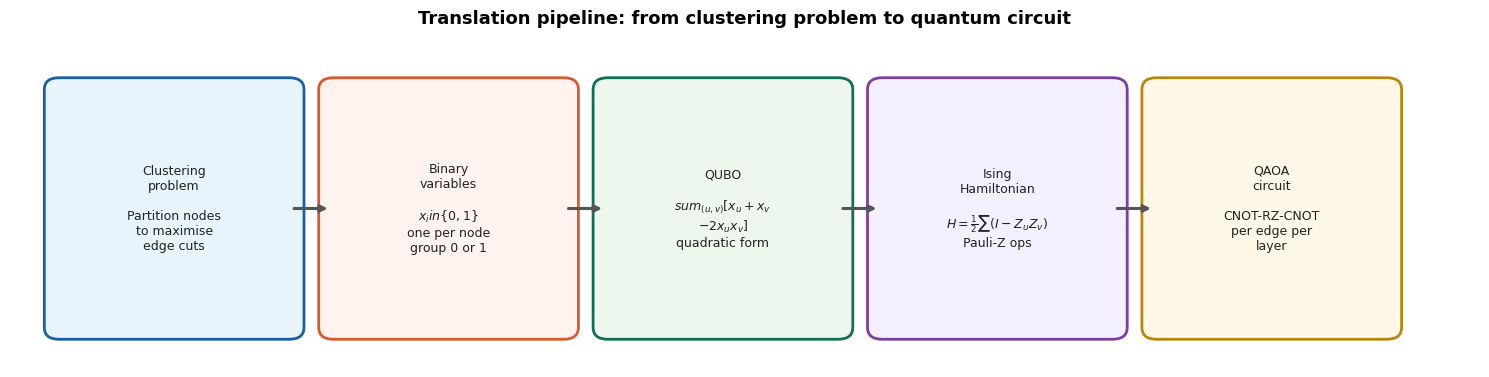

In [ ]:
# QUBO translation pipeline flowchart
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(15, 3.8))
ax.set_xlim(0, 15); ax.set_ylim(0, 4); ax.axis("off")
fig.suptitle("Translation pipeline: from clustering problem to quantum circuit",
             fontsize=13, fontweight="bold")

steps_info = [
    ("Clustering\nproblem\n\nPartition nodes\nto maximise\nedge cuts",          "#E8F4FB", "#185FA5"),
    ("Binary\nvariables\n\n$x_i in \{0,1\}$\none per node\ngroup 0 or 1",  "#FFF3EF", "#D85A30"),
    ("QUBO\n\n$sum_{(u,v)}[x_u + x_v$\n$- 2x_u x_v]$\nquadratic form",        "#EEF7EE", "#0F6E56"),
    ("Ising\nHamiltonian\n\n$H=\\frac{1}{2}\sum(I-Z_u Z_v)$\nPauli-Z ops",  "#F5F0FF", "#7B3FA0"),
    ("QAOA\ncircuit\n\nCNOT-RZ-CNOT\nper edge per\nlayer",                      "#FFF8E8", "#B8860B"),
]
bw = 2.35
for i, (text, fc, ec) in enumerate(steps_info):
    x = 0.5 + i * (bw + 0.45)
    ax.add_patch(FancyBboxPatch((x, 0.5), bw, 3.0,
                                boxstyle="round,pad=0.15", facecolor=fc, edgecolor=ec, lw=2))
    ax.text(x + bw/2, 2.0, text, ha="center", va="center",
            fontsize=9, color="#222", multialignment="center")
    if i < len(steps_info) - 1:
        ax.annotate("", xy=(x + bw + 0.42, 2.0), xytext=(x + bw + 0.02, 2.0),
                    arrowprops=dict(arrowstyle="->", color="#555", lw=2.2))

plt.tight_layout()
plt.show()

**Step 3:** Classical brute force baseline

Before trusting QAOA we need the right answer. For 5 nodes we can check all
32 partitions exhaustively. This is the ground truth QAOA will be measured against.

Brute force: checking all 2^5 = 32 possible partitions

Optimal partition: [0, 0, 1, 1, 0]
Optimal cut value: 5 out of 6 edges



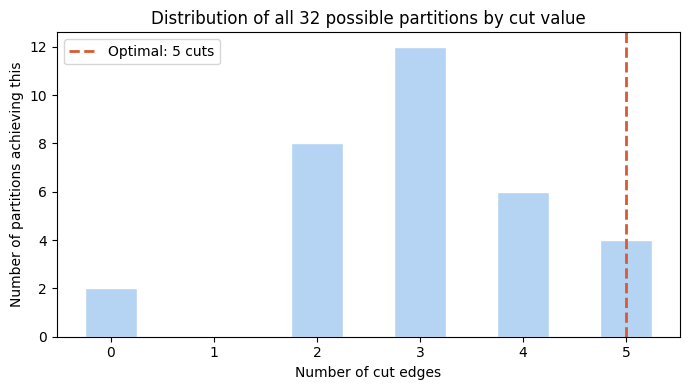

Only 4 out of 32 partitions achieve the optimal cut.
For a graph with 50 nodes, brute force would check 2^50 = 1,125,899,906,842,624 partitions.


In [ ]:
# Classical brute force: check every possible partition
# This is what we want to beat (at larger scales, not here)

def count_cut_edges(partition, graph):
    """Count edges crossing between the two groups"""
    return sum(1 for u, v in graph.edges()
               if partition[u] != partition[v])

print('Brute force: checking all 2^5 = 32 possible partitions')
print()

n_nodes = G.number_of_nodes()
best_cut = 0
best_partition = None
all_results = []

for i in range(2**n_nodes):
    partition = [int(b) for b in format(i, f'0{n_nodes}b')]
    cut_val = count_cut_edges(partition, G)
    all_results.append((partition, cut_val))
    if cut_val > best_cut:
        best_cut = cut_val
        best_partition = partition

print(f'Optimal partition: {best_partition}')
print(f'Optimal cut value: {best_cut} out of {G.number_of_edges()} edges')
print()

from collections import Counter
cut_distribution = Counter(r[1] for r in all_results)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cut_distribution.keys(), cut_distribution.values(),
       color='#B5D4F4', edgecolor='white', width=0.5)
ax.axvline(best_cut, color='#D85A30', lw=2, linestyle='--',
           label=f'Optimal: {best_cut} cuts')
ax.set_xlabel('Number of cut edges')
ax.set_ylabel('Number of partitions achieving this')
ax.set_title('Distribution of all 32 possible partitions by cut value')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Only {cut_distribution[best_cut]} out of 32 partitions achieve the optimal cut.')
print(f'For a graph with 50 nodes, brute force would check 2^50 = {2**50:,} partitions.')

**Step 4:** Now let's build and tune the QAOA circuit

We are building the circuit from the translation pipeline and optimise its parameters with a classical optimiser. Circuit depth p = 2 means two alternating cost + mixer layers.

In [ ]:
# QAOA: build the circuit following the translation pipeline above.
# Each ZZ coupling in H_cost compiles to CNOT then RZ(2*gamma) then CNOT.

edges = list(G.edges())
n_qubits_qaoa = G.number_of_nodes()
p = 2  # Number of QAOA layers (depth). Higher p = more expressive, harder to optimize.

def build_qaoa_circuit(gammas, betas):
    qc = QuantumCircuit(n_qubits_qaoa, n_qubits_qaoa)

    # Initial state: equal superposition over all 2^n partitions
    qc.h(range(n_qubits_qaoa))

    for gamma, beta in zip(gammas, betas):
        # Cost operator: e^{-i gamma H_cost} where H_cost = (1/2) sum (I - Z_u Z_v)
        # Drop the identity part (global phase); each Z_u Z_v term becomes CX-RZ-CX
        for u, v in edges:
            qc.cx(u, v)
            qc.rz(2 * gamma, v)
            qc.cx(u, v)

        # Mixer operator: e^{-i beta H_mixer} with H_mixer = sum X_i
        # Each X_i becomes rx(2*beta) on qubit i
        for i in range(n_qubits_qaoa):
            qc.rx(2 * beta, i)

    qc.measure(range(n_qubits_qaoa), range(n_qubits_qaoa))
    return qc

# Test with a fixed set of parameters first
test_gammas = [0.5, 1.0]
test_betas  = [0.3, 0.7]
qc_test = build_qaoa_circuit(test_gammas, test_betas)

print('QAOA circuit (2 layers):')
print(qc_test.draw('text'))

QAOA circuit (2 layers):
     ┌───┐                                      ┌─────────┐                   »
q_0: ┤ H ├──■─────────────■────■─────────────■──┤ Rx(0.6) ├───────────────────»
     ├───┤┌─┴─┐┌───────┐┌─┴─┐  │             │  └─────────┘                   »
q_1: ┤ H ├┤ X ├┤ Rz(1) ├┤ X ├──┼─────────────┼───────■────────────────■────■──»
     ├───┤└───┘└───────┘└───┘┌─┴─┐┌───────┐┌─┴─┐   ┌─┴─┐   ┌───────┐┌─┴─┐  │  »
q_2: ┤ H ├───────────────────┤ X ├┤ Rz(1) ├┤ X ├───┤ X ├───┤ Rz(1) ├┤ X ├──┼──»
     ├───┤                   └───┘└───────┘└───┘   └───┘   └───────┘└───┘┌─┴─┐»
q_3: ┤ H ├───────────────────────────────────────────────────────────────┤ X ├»
     ├───┤                                                               └───┘»
q_4: ┤ H ├────────────────────────────────────────────────────────────────────»
     └───┘                                                                    »
c: 5/═════════════════════════════════════════════════════════════════════════»
               

**Step 5:** Now we will optimize the QAOA parameters and find the best partition

In [ ]:
# Optimize QAOA parameters and find the best partition
from scipy.optimize import minimize

def expected_cut_value(params):
    """Compute expected cut value for given QAOA parameters"""
    gammas = params[:p]
    betas  = params[p:]
    qc = build_qaoa_circuit(gammas, betas)
    counts = simulator.run(qc, shots=2000).result().get_counts()
    total = sum(counts.values())

    expected = 0
    for bitstring, count in counts.items():
        partition = [int(b) for b in bitstring]
        cut_val = count_cut_edges(partition, G)
        expected += (count / total) * cut_val

    return -expected  # Negative because we minimize

print('Optimizing QAOA parameters...')
print('(QAOA is a heuristic: final approximation ratio varies across runs.')
print(' Seeing 0.85-1.0 is typical. Not seeing 1.0 every time is expected behavior.)')
print()

# Seed the random starts so this cell is reproducible
rng_qaoa = np.random.default_rng(SEED)

best_val = 0
best_params = None

# Multiple random restarts to reduce local-minima trap risk
for trial in range(6):
    x0 = rng_qaoa.uniform(0, np.pi, 2 * p)
    result = minimize(expected_cut_value, x0,
                      method='COBYLA',
                      options={'maxiter': 300})
    if -result.fun > best_val:
        best_val = -result.fun
        best_params = result.x
    print(f'  Trial {trial+1}: expected cut = {-result.fun:.3f}')

print(f'\nBest expected cut value: {best_val:.3f}')
print(f'Optimal cut (brute force): {best_cut}')
print(f'Approximation ratio: {best_val/best_cut:.3f} (1.0 = optimal)')

Optimizing QAOA parameters...
(QAOA is a heuristic: final approximation ratio varies across runs.
 Seeing 0.85-1.0 is typical. Not seeing 1.0 every time is expected behavior.)

  Trial 1: expected cut = 4.268
  Trial 2: expected cut = 3.790
  Trial 3: expected cut = 4.339
  Trial 4: expected cut = 3.788
  Trial 5: expected cut = 3.905
  Trial 6: expected cut = 3.957

Best expected cut value: 4.339
Optimal cut (brute force): 5
Approximation ratio: 0.868 (1.0 = optimal)


**Step 6:** What did QAOA find?

Most probable QAOA partition: [1, 1, 0, 0, 1]
Cut value: 5 (optimal is 5)


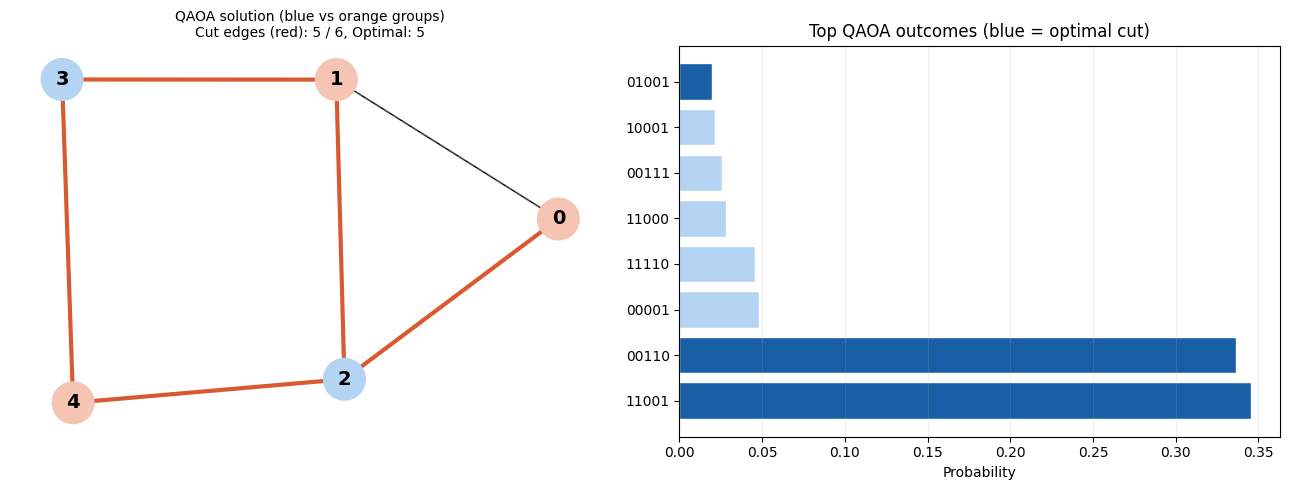


Blue bars = partitions that achieve the optimal cut.
QAOA concentrates probability mass on good solutions.
This is the quantum equivalent of a smart search.


In [ ]:
# Find and visualize the best partition QAOA found
opt_gammas = best_params[:p]
opt_betas  = best_params[p:]
qc_opt = build_qaoa_circuit(opt_gammas, opt_betas)

counts_opt = simulator.run(qc_opt, shots=8000).result().get_counts()
total = sum(counts_opt.values())

# Find the most probable partition (bug-free version: key=dict.get, not bare max)
best_measured = max(counts_opt, key=counts_opt.get)
qaoa_partition = [int(b) for b in best_measured]
qaoa_cut = count_cut_edges(qaoa_partition, G)

print(f'Most probable QAOA partition: {qaoa_partition}')
print(f'Cut value: {qaoa_cut} (optimal is {best_cut})')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Show the partition on the graph
node_colors = ['#B5D4F4' if b == 0 else '#F5C4B3'
               for b in qaoa_partition]
cut_edges = [(u, v) for u, v in edges
             if qaoa_partition[u] != qaoa_partition[v]]
uncut_edges = [(u, v) for u, v in edges
               if qaoa_partition[u] == qaoa_partition[v]]

nx.draw(G, pos, ax=axes[0],
        with_labels=True,
        node_color=node_colors,
        node_size=900, font_size=14, font_weight='bold')
nx.draw_networkx_edges(G, pos, edgelist=cut_edges, ax=axes[0],
                       edge_color='#D85A30', width=3)
nx.draw_networkx_edges(G, pos, edgelist=uncut_edges, ax=axes[0],
                       edge_color='gray', width=1.5,
                       style='dashed', alpha=0.5)
axes[0].set_title(
    f'QAOA solution (blue vs orange groups)\n'
    f'Cut edges (red): {qaoa_cut} / {G.number_of_edges()}, '
    f'Optimal: {best_cut}',
    fontsize=10
)

# Show probability distribution over top partitions
sorted_counts = sorted(counts_opt.items(), key=lambda x: -x[1])[:8]
labels = [s[0] for s in sorted_counts]
values = [s[1]/total for s in sorted_counts]
bar_colors = ['#185FA5' if count_cut_edges([int(b) for b in s], G) == best_cut
              else '#B5D4F4'
              for s, _ in sorted_counts]

axes[1].barh(range(len(labels)), values, color=bar_colors, edgecolor='white')
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels(labels, fontsize=10)
axes[1].set_xlabel('Probability')
axes[1].set_title('Top QAOA outcomes (blue = optimal cut)')
axes[1].grid(alpha=0.2, axis='x')

plt.tight_layout()
plt.show()

print()
print('Blue bars = partitions that achieve the optimal cut.')
print('QAOA concentrates probability mass on good solutions.')
print('This is the quantum equivalent of a smart search.')

**Question:** QAOA does not always find the *exact* optimal solution. In what situations would an
approximate solution be acceptable in a data science workflow?
Give a real example.

# **Milestone 6: Quantum Hardware**

Everything so far ran on a perfect classical simulator. Real quantum hardware is fundamentally different.

This milestone covers noise, a key factor on quantum computing. We will also run some code on an actual IBM quantum hardware and guide you through it. Let's start!

**Step 1:** Let's visualize the noise taxonomy and the four main error types

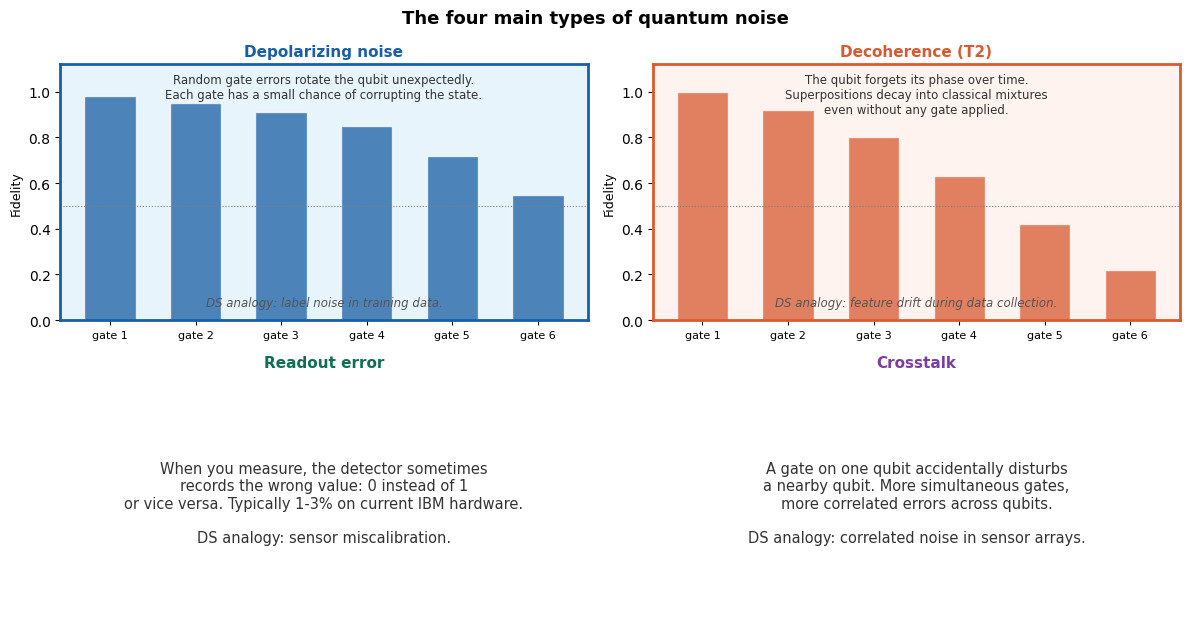

In [ ]:
# Noise taxonomy, a visual guide to the four main error types
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
fig.suptitle("The four main types of quantum noise", fontsize=13, fontweight="bold")

noise_info = [
    ("Depolarizing noise",
     "Random gate errors rotate the qubit unexpectedly.\nEach gate has a small chance of corrupting the state.\n\nDS analogy: label noise in training data.",
     "#E8F4FB", "#185FA5", [0.98, 0.95, 0.91, 0.85, 0.72, 0.55]),
    ("Decoherence (T2)",
     "The qubit forgets its phase over time.\nSuperpositions decay into classical mixtures\neven without any gate applied.\n\nDS analogy: feature drift during data collection.",
     "#FFF3EF", "#D85A30", [1.0, 0.92, 0.80, 0.63, 0.42, 0.22]),
    ("Readout error",
     "When you measure, the detector sometimes\nrecords the wrong value: 0 instead of 1\nor vice versa. Typically 1-3% on current IBM hardware.\n\nDS analogy: sensor miscalibration.",
     "#EEF7EE", "#0F6E56", None),
    ("Crosstalk",
     "A gate on one qubit accidentally disturbs\na nearby qubit. More simultaneous gates,\nmore correlated errors across qubits.\n\nDS analogy: correlated noise in sensor arrays.",
     "#F5F0FF", "#7B3FA0", None),
]

for ax, (title, desc, fc, ec, decay) in zip(axes.flat, noise_info):
    ax.set_facecolor(fc)
    for spine in ax.spines.values():
        spine.set_edgecolor(ec); spine.set_linewidth(2)
    ax.set_title(title, fontsize=11, fontweight="bold", color=ec, pad=6)

    if decay is not None:
        x = np.arange(len(decay))
        ax.bar(x, decay, color=ec, alpha=0.75, edgecolor="white", width=0.6)
        ax.set_ylim(0, 1.12); ax.set_xticks(x)
        ax.set_xticklabels([f"gate {i+1}" for i in range(len(decay))], fontsize=8)
        ax.set_ylabel("Fidelity", fontsize=9)
        ax.axhline(0.5, color="gray", lw=0.8, linestyle=":")
        body, analogy = desc.split("\n\nDS analogy: ")
        ax.text(2.5, 1.08, body, fontsize=8.5, ha="center", va="top", color="#333")
        ax.text(2.5, 0.06, f"DS analogy: {analogy}",
                fontsize=8.5, ha="center", style="italic", color="#555")
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, desc, ha="center", va="center",
                transform=ax.transAxes, fontsize=10.5, color="#333",
                multialignment="center")

plt.tight_layout()
plt.show()

**Step 2**: Now let's see noise in action using a simulated noisy backend.

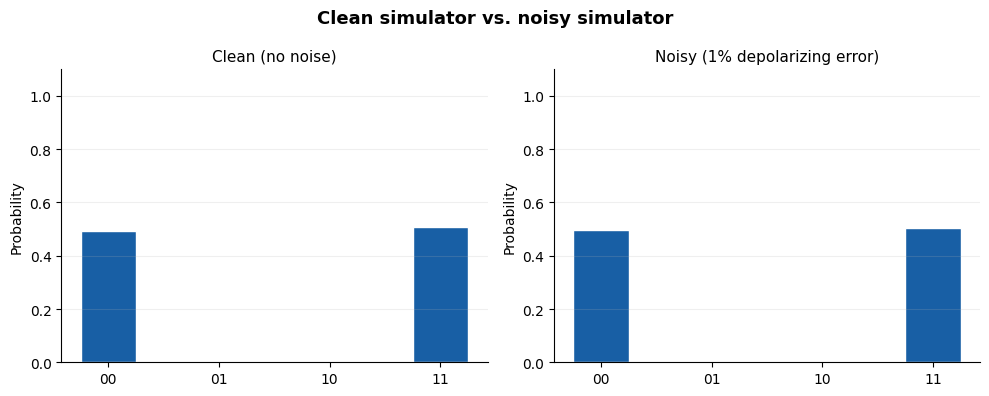

Clean:  only |00> and |11> appear — perfect Bell state
Noisy:  |01> and |10> leak in — noise corrupting the result


In [ ]:
# See noise in action using a simulated noisy backend
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Build a simple noise model: 1% error per gate
noise_model = NoiseModel()
error = depolarizing_error(0.01, 1)
noise_model.add_all_qubit_quantum_error(error, ['h', 'x'])

noisy_simulator = AerSimulator(noise_model=noise_model, seed_simulator=SEED)

# Run a Bell state circuit with and without noise
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0)
qc_bell.cx(0, 1)
qc_bell.measure([0, 1], [0, 1])

counts_clean = simulator.run(qc_bell, shots=4000).result().get_counts()
counts_noisy = noisy_simulator.run(qc_bell, shots=4000).result().get_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Clean simulator vs. noisy simulator", fontsize=13, fontweight="bold")

for ax, counts, title in zip(axes,
    [counts_clean, counts_noisy],
    ["Clean (no noise)", "Noisy (1% depolarizing error)"]):
    states = ["00", "01", "10", "11"]
    probs = [counts.get(s, 0) / 4000 for s in states]
    ax.bar(states, probs,
           color=["#185FA5" if s in ["00", "11"] else "#D85A30" for s in states],
           edgecolor="white", width=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1.1)
    ax.grid(alpha=0.2, axis="y")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("Clean:  only |00> and |11> appear — perfect Bell state")
print("Noisy:  |01> and |10> leak in — noise corrupting the result")

**Step 3**: Let's see how noise gets worse as circuits get deeper.

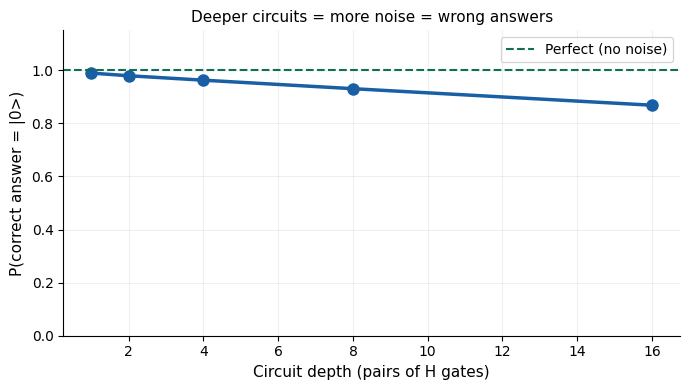

A perfect circuit always returns |0> — H·H cancels out.
But noise accumulates with each gate, pushing the answer away from 1.0.


In [ ]:
# Noise compounds with circuit depth
depths = [1, 2, 4, 8, 16]
fidelities = []

for depth in depths:
    qc = QuantumCircuit(1, 1)
    for _ in range(depth):
        qc.h(0)
        qc.h(0)  # H·H = identity, so a perfect circuit always returns |0>
    qc.measure(0, 0)

    counts = noisy_simulator.run(qc, shots=4000).result().get_counts()
    p0 = counts.get("0", 0) / 4000
    fidelities.append(p0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, fidelities, "o-", color="#185FA5", lw=2.5, markersize=8)
ax.axhline(1.0, color="#0F6E56", lw=1.5, linestyle="--", label="Perfect (no noise)")
ax.set_xlabel("Circuit depth (pairs of H gates)", fontsize=11)
ax.set_ylabel("P(correct answer = |0>)", fontsize=11)
ax.set_title("Deeper circuits = more noise = wrong answers", fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("A perfect circuit always returns |0> — H·H cancels out.")
print("But noise accumulates with each gate, pushing the answer away from 1.0.")

**Question:** Looking back at the four noise types from Step 1. Which one does the error above most resemble in a data science context, and why? What would you do in a classical ML pipeline to handle that kind of noise?

**Ans:**

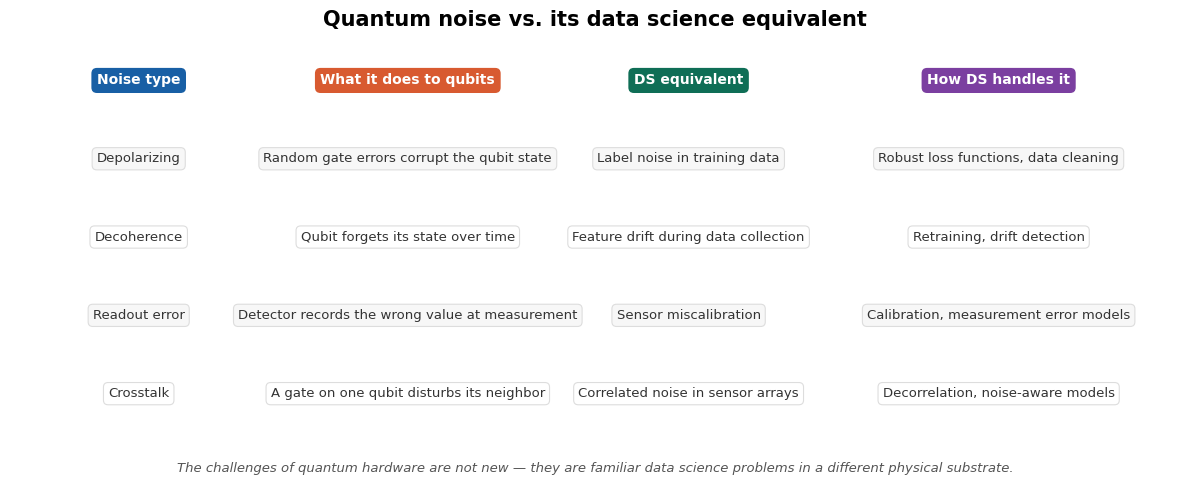

In [ ]:
# Quantum noise vs. classical data science: a side-by-side comparison

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")
fig.suptitle("Quantum noise vs. its data science equivalent",
             fontsize=15, fontweight="bold")

headers = ["Noise type", "What it does to qubits", "DS equivalent", "How DS handles it"]
rows = [
    ("Depolarizing",  "Random gate errors corrupt the qubit state",
     "Label noise in training data",          "Robust loss functions, data cleaning"),
    ("Decoherence",   "Qubit forgets its state over time",
     "Feature drift during data collection",  "Retraining, drift detection"),
    ("Readout error", "Detector records the wrong value at measurement",
     "Sensor miscalibration",                 "Calibration, measurement error models"),
    ("Crosstalk",     "A gate on one qubit disturbs its neighbor",
     "Correlated noise in sensor arrays",     "Decorrelation, noise-aware models"),
]

col_x = [0.01, 0.22, 0.47, 0.70]
col_w = [0.20, 0.24, 0.22, 0.29]
colors = ["#185FA5", "#D85A30", "#0F6E56", "#7B3FA0"]

for j, (h, x, w) in enumerate(zip(headers, col_x, col_w)):
    ax.text(x + w / 2, 0.93, h, transform=ax.transAxes,
            ha="center", va="center", fontsize=10, fontweight="bold",
            color="white",
            bbox=dict(boxstyle="round,pad=0.4", facecolor=colors[j], edgecolor="none"))

for i, (noise, qubit_effect, ds_equiv, ds_fix) in enumerate(rows):
    y = 0.75 - i * 0.18
    bg = "#F7F7F7" if i % 2 == 0 else "white"
    for j, (val, x, w) in enumerate(zip(
            [noise, qubit_effect, ds_equiv, ds_fix], col_x, col_w)):
        ax.text(x + w / 2, y, val, transform=ax.transAxes,
                ha="center", va="center", fontsize=9.5, color="#333",
                bbox=dict(boxstyle="round,pad=0.35", facecolor=bg,
                          edgecolor="#ddd", lw=0.8))

ax.text(0.5, 0.03,
        "The challenges of quantum hardware are not new — they are familiar data science problems in a different physical substrate.",
        transform=ax.transAxes, ha="center", fontsize=9.5,
        style="italic", color="#555")

plt.tight_layout()
plt.show()

****

<h3 align = 'center' >
Thank you for completing the project!
</h3>

Please submit all materials to the NSDC HQ team at nsdc@columbia.edu
 in order to receive a virtual certificate of completion. Do reach out to us if you have any questions or concerns. We are here to help you learn and grow.